# Notebook 03 — Enhanced Content-Based Recommender

**Module:** ITI113 Machine Learning & Operations
**Focus Area:** C — Unsupervised / Similarity Search
**Project:** *Enhanced content-based recommender* — Top-N most similar listings in an **enriched feature space** (listing features + Task 1 predicted fair price + Task 2 predicted instant-booking probability)

---

## What this notebook does

1. **Consumes the Notebook 01 preprocessing contract for real** — rebuilds the full-catalog feature matrix from `preprocessing_artifacts.json` (deterministic replay + frozen train-fitted transforms), this time **retaining `listing_id`** as an opaque join key and keeping a human-readable display frame for showing recommendations
2. Reproduces the Task 1 train/test split deterministically and **verifies the rebuild numerically** against the saved processed matrices — the consistency proof that this notebook and Notebook 02 are reasoning about byte-identical features
3. **Generates the two enrichment signals** — predicted fair log-price (Task 1 champion via `best_model.json` → MLflow / S3 mirror, or an inline out-of-fold surrogate) and predicted instant-booking probability (Task 2 champion via Jestin's frozen contract replay, or an inline surrogate) — with per-task graceful fallback and full provenance reporting
4. Fixes the **currency problem in the predicted price** (within-city standardisation on train-fitted moments) so "fair value" is comparable across ten currencies
5. Runs a **recommender-shaped mini-EDA** of the similarity space — block anatomy, enrichment-vs-raw-feature redundancy, the similarity-feature whitelist, the cross-city question, and distance diagnostics — each subsection feeding an explicit design decision
6. Builds the recommender: block-weighted, variance-standardised, L2-normalised vectors → per-city cosine similarity indexes → an explainable `recommend()` with **per-block similarity decomposition**
7. Evaluates without interaction labels: deterministic **case studies**, quantitative **attribute-coherence vs a random baseline**, and the **naive-vs-enriched ablation** that measures the project's differentiator claim, plus diversity and latency
8. Persists the catalog, vectors and `recommender_artifacts.json`, and (optionally) logs the build to the team MLflow App under a distinct `notebook` tag

## Problem framing (read this first)

- **Task:** unsupervised, content-based similarity search. Given a query `listing_id`, return the Top-N listings whose **enriched feature vectors** are closest under cosine similarity. There is no training target and no interaction data anywhere in this task.
- **What a recommendation means:** *"listings most like this one — in what they are (structure, location, amenities, host, stay terms) **and** in what our models infer about them (fair advertised rate, booking friction)."* It is **not** a prediction of what a guest will click, book or enjoy: the dataset contains no guest behaviour, so any such claim would be unfounded.
- **The differentiator:** the outputs of Tasks 1 and 2 are appended to the feature vectors, so the recommender reasons about *inferred fair value* and *inferred booking friction*, not only observable attributes. Section 5.2 measures exactly what that enrichment changes versus a naive content-only recommender.
- **Temporal scope:** inherited from Notebook 01 — the snapshot is early-2021; this is a retrainable methodology, not current market guidance.

## Known limitations and how this notebook handles them

| # | Limitation | Handling strategy (section) |
|---|------------|------------------------------|
| 1 | No interaction data → no click/booking-based evaluation | Evaluate with attribute-coherence vs a random baseline, a naive-vs-enriched ablation, diversity and case studies; claims are scoped accordingly (Step 5, Step 7) |
| 2 | Predicted price is in **local currency** (log scale) — it encodes *city*, not value | Within-city standardisation of the predicted log price on **train-fitted** moments (Step 2.4) |
| 3 | Enrichment quality is bounded by Task 1/2 model quality; train rows get in-sample champion predictions | Surrogates use out-of-fold predictions; champion mode documents the in-sample caveat and cross-checks test metrics against `best_model.json` (Step 2.3) |
| 4 | Cosine distance is dominated by whichever feature block has the most columns / largest spread | Per-column variance standardisation + per-**block** weight budget `sqrt(w_b / n_b)` so a block's expected distance contribution equals its configured weight (Step 3.1, Step 4.1) |
| 5 | Data-quality flags (`*_missing`) would make listings "similar" for sharing gaps, not properties | Explicit similarity-feature whitelist with per-exclusion rationale, asserted (Step 3.3) |
| 6 | The two upstream pipelines filter rows differently and neither saved matrix carries `listing_id` | One **canonical catalog** rebuilt under the stricter Task 1 rules with `listing_id` retained; Task 2 enrichment is computed by replaying Jestin's frozen contract on the canonical rows and joining on `listing_id` (Step 1, Step 2.2) |

## Expected setup from Notebooks 01 / 02

- **Task 1 (required):** `preprocessing_artifacts.json` (+ optionally the four processed CSVs for the verification proof) under `processed/` locally or `s3://{BUCKET}/{PREFIX_TASK1}/processed/`; the raw `Listings.csv` next to this notebook, under `./data/`, or at `s3://{BUCKET}/{PREFIX_TASK1}/raw/Listings.csv`
- **Task 1 champion (optional, for champion mode):** `best_model.json` locally or at `s3://{BUCKET}/{PREFIX_TASK1}/artifacts/best_model.json`, with the model loadable from the MLflow App or from the Section 8A mirror `s3://{BUCKET}/{PREFIX_TASK1}/artifacts/champion/<run_id>/`
- **Task 2 champion (optional, for champion mode):** Jestin's `best_model.json` and his preprocessing artifacts JSON under the instant-booking prefix; the model loadable from the MLflow App at `runs:/<id>/best_model`
- If any optional piece is unreachable, the notebook **falls back per task to an inline surrogate** (same HGB family as the Task 1 champion) and says so loudly — the whole notebook still runs end-to-end locally with only `Listings.csv` + the Task 1 artifacts JSON.

## Prerequisites

- SageMaker Studio, kernel Python 3 (Data Science 3.0), instance ml.t3.medium — also runs locally; S3 and MLflow steps degrade gracefully
- SageMaker execution role with S3 read/write on the default bucket (Studio only)

In [1]:
# # SageMaker Studio first run only — uncomment, run, then RESTART the kernel.
# # (Skip when running locally.)
# %pip install --upgrade --force-reinstall "sagemaker>=2,<3" boto3 botocore
# %pip install --upgrade mlflow sagemaker-mlflow

## 0. Configuration

Edit the values in this cell; everything else references these variables. Design points worth flagging:

- **`ENRICHMENT_MODE`** — `"auto"` (default) tries each task's champion and falls back to an inline surrogate per task; `"champion"` fails loudly if a champion is unreachable; `"surrogate"` skips MLflow/S3 model loading entirely. Provenance is recorded in `recommender_artifacts.json` either way, so a reader always knows which models produced the enrichment.
- **`BLOCK_WEIGHTS`** are the recommender's *policy constants*: each block's total budget in the (squared) distance, regardless of how many columns the block contains. Section 3.1 verifies empirically that realised contributions match these numbers; Section 5.2's ablation sets `enrichment` to 0 to build the naive comparison space.
- **`SAME_CITY_ONLY = True`** makes geography a *candidate filter*, not a similarity dimension (Section 3.4 justifies this). Setting it to `False` switches to a deliberately **city-blind** space ("find this listing's equivalent in another market"), in which the coarse coordinates are automatically excluded because they would smuggle city identity back in.
- Nothing here re-estimates any Notebook 01 statistic — every train-fitted constant is read from `preprocessing_artifacts.json`.

In [2]:
import os, io, re, json, glob, time, warnings, tempfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

# ---- environment: SageMaker if available, otherwise local fallback ----
try:
    import sagemaker, boto3
    session = sagemaker.Session()
    role    = sagemaker.get_execution_role()
    REGION  = boto3.Session().region_name
    s3      = boto3.client("s3")
    LOCAL_MODE = False
except Exception:
    try:
        import boto3                       # plain AWS credentials without SageMaker
        s3 = boto3.client("s3")
        s3.list_buckets()
        REGION = boto3.Session().region_name
        LOCAL_MODE = False
        session = role = None
    except Exception:
        session = role = REGION = s3 = None
        LOCAL_MODE = True

TEAM_ID    = "team14"    # <- change to your team
STUDENT_ID = "s1402"     # <- change to your student id

BUCKET       = "nyp-26s1-iti113"
PREFIX_TASK1 = f"iti113/{TEAM_ID}/data/airbnb-listings"          # Notebook 01/02 (regression)
PREFIX_TASK2 = f"iti113/{TEAM_ID}/data/airbnb-instant-booking"   # Jestin's 01/02 (classification)
PREFIX_TASK3 = f"iti113/{TEAM_ID}/data/airbnb-recommender"       # this notebook's outputs

LOCAL_PROCESSED_TASK1 = "processed"                    # Notebook 01 local fallback output
LOCAL_OUT             = "recommender_out"              # this notebook's local fallback output

# ---- data source (same candidates as Notebook 01, plus the S3 raw copy it uploaded) ----
DATA_CANDIDATES = ["Listings.csv", os.path.join("data", "Listings.csv"),
                   "/mnt/user-data/uploads/Listings.csv"]

# ---- reproducibility ----
RANDOM_STATE = 42        # must match Notebook 01 (asserted against the artifacts JSON)

# ---- recommender policy constants ----
TOP_N_DEFAULT     = 10
SIMILARITY_METRIC = "cosine"     # documented; the implementation L2-normalises + brute cosine
SAME_CITY_ONLY    = True         # geography as candidate filter (Section 3.4); False = city-blind space
ENRICHMENT_MODE   = "auto"       # "auto" | "champion" | "surrogate"
OOF_FOLDS         = 5            # out-of-fold predictions for surrogate enrichment on train rows
N_EVAL_QUERIES    = 250          # sample size for Section 5.2 quantitative evaluation
N_PAIR_SAMPLE     = 30000        # same-city pairs for Section 3.1 distance anatomy

# Per-BLOCK weight budget in the squared distance (not per column — Section 3.1/4.1).
BLOCK_WEIGHTS = {
    "structure":  1.00,   # capacity, configuration, room type, property group
    "location":   1.00,   # within-city geography: centrality, supply density, coarse cells
    "amenities":  1.00,   # top-30 flags + counts (variance-standardised -> IDF-like)
    "enrichment": 1.00,   # THE differentiator: fair-value z + booking-friction probability
    "stay_terms": 0.50,   # minimum/maximum nights, monthly-minimum regime
    "host":       0.50,   # tenure, responsiveness, scale, badges
    "reviews":    0.50,   # 7 guest-perception scores + review presence
}

# ---- champion discovery (all optional; used only when ENRICHMENT_MODE != "surrogate") ----
DEFAULT_MLFLOW_APP_ARN = ""      # optional hard-coded fallback ARN, as in Notebook 02
MLFLOW_CONFIG_GLOB     = f"mlflow_app_config_{TEAM_ID}*.json"
LOG_TO_MLFLOW          = True    # log this build as a run tagged notebook="03_recommender"
MLFLOW_EXPERIMENT_T3   = f"{TEAM_ID}-recommender"

TASK1_BEST_JSON_CANDIDATES = ["best_model.json", "best_model_task1.json",
                              "task1/best_model.json"]
TASK2_BEST_JSON_CANDIDATES = ["best_model_task2.json", "best_model_instant_booking.json",
                              "task2/best_model.json", "best_model.json"]
TASK2_ARTS_CANDIDATES      = ["01_preprocessing_artifacts.json", "preprocessor_artifacts.json",
                              os.path.join("processed_instant_booking", "preprocessor_artifacts.json"),
                              os.path.join("airbnb_processed", "01_preprocessing_artifacts.json")]

print(f"Mode            : {'LOCAL (no AWS/S3)' if LOCAL_MODE else 'AWS (S3 reachable)'}")
if not LOCAL_MODE:
    print(f"Bucket          : {BUCKET}")
    print(f"Task 1 prefix   : {PREFIX_TASK1}")
    print(f"Task 2 prefix   : {PREFIX_TASK2}")
    print(f"Task 3 prefix   : {PREFIX_TASK3}")
print(f"Team / Student  : {TEAM_ID} / {STUDENT_ID}")
print(f"Enrichment mode : {ENRICHMENT_MODE} | same-city filter: {SAME_CITY_ONLY}")
print(f"Block weights   : {BLOCK_WEIGHTS}")
print(f"numpy {np.__version__} | pandas {pd.__version__}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Mode            : AWS (S3 reachable)
Bucket          : nyp-26s1-iti113
Task 1 prefix   : iti113/team14/data/airbnb-listings
Task 2 prefix   : iti113/team14/data/airbnb-instant-booking
Task 3 prefix   : iti113/team14/data/airbnb-recommender
Team / Student  : team14 / s1402
Enrichment mode : auto | same-city filter: True
Block weights   : {'structure': 1.0, 'location': 1.0, 'amenities': 1.0, 'enrichment': 1.0, 'stay_terms': 0.5, 'host': 0.5, 'reviews': 0.5}
numpy 1.26.4 | pandas 2.3.3


## 1. Rebuild the Canonical Catalog from the Notebook 01 Contract

Notebook 01 called its artifacts JSON a *"reproducible preprocessing contract: a scoring service can transform a brand-new listing without ever re-touching the training data."* This section is that contract being consumed for real — with three deliberate deltas, each required by the recommender and none of them touching any fitted statistic:

1. **Full catalog, not the 80/20 split.** The split exists to evaluate supervised models; a recommender must be able to retrieve *any* valid listing. The split is still reproduced (Step 1.3) — but only to verify the rebuild, to keep the surrogate/champion evaluation honest, and to fit the few *new* train-only moments this notebook introduces (enrichment standardisation, vector column scaling).
2. **`listing_id` is retained** as an opaque join key. Neither upstream saved matrix carries it, yet a recommender is *defined* by "query id → similar ids". It stays outside the similarity vector, exactly as Notebook 01's whitelist discipline demands.
3. **A display frame is kept** (city, room type, property group, capacity, price, stay terms…) so recommendations can be *shown and sanity-checked* by a human. It also lives outside the vector.

Why the stricter Task 1 row rules define the canonical catalog: Task 1 removes `price ≤ 0`, `accommodates ≤ 0` **and near-duplicate re-posts**; Task 2 removes only `price ≤ 0`. The canonical set is therefore a subset of both pipelines' domains — every canonical row can be scored by *both* champions — and the near-duplicate removal is worth extra for a recommender, where re-posted units would otherwise fill the Top-N with the same physical property.

In [3]:
# ==============================================================================
# 1.0  LOAD THE PREPROCESSING CONTRACT + RAW DATA
# ==============================================================================
def _s3_read_bytes(bucket, key):
    r = s3.get_object(Bucket=bucket, Key=key)
    return r["Body"].read()

def load_json_any(local_candidates, s3_keys, what):
    for p in local_candidates:
        if p and os.path.exists(p):
            print(f"{what}: local  {p}")
            return json.loads(Path(p).read_text()), f"local:{p}"
    if not LOCAL_MODE:
        for key in s3_keys:
            try:
                obj = json.loads(_s3_read_bytes(BUCKET, key))
                print(f"{what}: s3     s3://{BUCKET}/{key}")
                return obj, f"s3://{BUCKET}/{key}"
            except Exception:
                continue
    return None, None

ARTS1, ARTS1_SOURCE = load_json_any(
    [os.path.join(LOCAL_PROCESSED_TASK1, "preprocessing_artifacts.json"),
     "preprocessing_artifacts.json"],
    [f"{PREFIX_TASK1}/processed/preprocessing_artifacts.json"],
    "Task 1 artifacts")
assert ARTS1 is not None, (
    "preprocessing_artifacts.json not found locally or on S3 — run Notebook 01 first "
    "(this notebook refuses to re-derive fitted statistics; the contract is the input).")

# ---- unpack the contract ---------------------------------------------------
POL            = ARTS1["policy_constants"]
CITY_CENTERS   = {k: tuple(v) for k, v in ARTS1["city_centers"].items()}
SNAPSHOT_DATE  = pd.Timestamp(ARTS1["snapshot_date"])
TEST_SIZE      = float(ARTS1["test_size"])
ALIASES        = dict(ARTS1["amenity_aliases"])
AMENITY_VOCAB  = list(ARTS1["amenity_vocab"])
IMPUTATION_VALUES  = dict(ARTS1["imputation_values"])
NEIGHBOURHOOD_FREQ = dict(ARTS1["neighbourhood_freq"])
HOST_COUNT_CAP     = float(ARTS1["host_count_cap"])
PRICE_CAPS         = dict(ARTS1["price_caps_per_city"])
ONEHOT_LEVELS      = dict(ARTS1["onehot_levels"])
RESPONSE_TIME_LEVELS = list(ARTS1["response_time_levels"])
SCALER_COLS   = list(ARTS1["scaler"]["columns"])
SCALER_MEAN   = np.asarray(ARTS1["scaler"]["mean"], dtype=np.float64)
SCALER_SCALE  = np.asarray(ARTS1["scaler"]["scale"], dtype=np.float64)
FEATURE_COLUMNS = list(ARTS1["feature_columns"])
REVIEW_COLS   = [c for c in IMPUTATION_VALUES if c.startswith("review_scores")]

assert int(ARTS1["random_state"]) == RANDOM_STATE, (
    f"RANDOM_STATE mismatch: notebook={RANDOM_STATE} vs artifacts={ARTS1['random_state']} — "
    "the split reproduction in Step 1.3 depends on these matching.")

# ---- raw data: local candidates first, then the S3 copy Notebook 01 uploaded ----
DATA_PATH, df_raw = None, None
for p in DATA_CANDIDATES:
    if os.path.exists(p):
        DATA_PATH = p
        df_raw = pd.read_csv(p, encoding="utf-8", encoding_errors="replace", low_memory=False)
        break
if df_raw is None and not LOCAL_MODE:
    try:
        DATA_PATH = f"s3://{BUCKET}/{PREFIX_TASK1}/raw/Listings.csv"
        df_raw = pd.read_csv(io.BytesIO(_s3_read_bytes(BUCKET, f"{PREFIX_TASK1}/raw/Listings.csv")),
                             encoding="utf-8", encoding_errors="replace", low_memory=False)
    except Exception:
        df_raw = None
assert df_raw is not None, ("Listings.csv not found locally or at the Notebook 01 raw S3 key — "
                            "place it next to this notebook or under ./data/.")

# keep a pristine copy: the Task 2 contract replay (Step 2.2) starts from RAW rows
df_raw = df_raw.reset_index(drop=True)
assert df_raw["listing_id"].duplicated().sum() == 0, "primary key violated in raw file"

print(f"Raw data        : {DATA_PATH}  ->  {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")
print(f"Contract        : {len(FEATURE_COLUMNS)} feature columns | snapshot {SNAPSHOT_DATE.date()} "
      f"| test_size {TEST_SIZE} | {len(AMENITY_VOCAB)} amenity vocab terms")
print(f"Audit trail     : {len(ARTS1['audit_log'])} cleaning steps recorded by Notebook 01")

Task 1 artifacts: local  processed/preprocessing_artifacts.json


Raw data        : Listings.csv  ->  279,712 rows x 33 cols
Contract        : 88 feature columns | snapshot 2021-03-01 | test_size 0.2 | 30 amenity vocab terms
Audit trail     : 7 cleaning steps recorded by Notebook 01


### 1.1 Deterministic replay — the fixed rules, re-executed in Notebook 01's exact order

Everything below is a **fixed rule** from Notebook 01 Steps 4–5 (constants, keyword rules, external reference points) — nothing is estimated from data, so replaying it on the full dataset is leak-free by the same *"statistic vs fixed function"* argument Notebook 01 committed to. Order is preserved **exactly** because Step 1.3's split reproduction depends on the surviving rows keeping their original relative order (filters and `keep='first'` de-duplication are order-preserving, so the row sequence entering `train_test_split` is identical to Notebook 01's).

Behaviour matches Notebook 01 line-for-line — including keeping `listing_id` as the opaque join key (Notebook 01 excluded it only from the *feature matrix*, and `host_id`/`name` are still destroyed immediately after their single de-duplication use). The recommender-specific delta comes later: this notebook also *exports* `listing_id` in the catalog, which the saved processed matrices never carried.

In [4]:
# ==============================================================================
# 1.1  DETERMINISTIC REPLAY (Notebook 01 Steps 4-5, exact order, listing_id kept)
# ==============================================================================
R_EARTH_KM = 6371.0
def haversine_km(lat1, lon1, lat2, lon2):
    p = np.pi / 180.0
    a = (np.sin((lat2 - lat1) * p / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 2 * R_EARTH_KM * np.arcsin(np.sqrt(a))

import ast
DASH_QUALIFIER = re.compile(r"\s+[\u2013\u2014-]\s+.*$")   # " – 1000 Mbps", " — In unit", " - 2 spaces"

def parse_amenities(raw):
    if not isinstance(raw, str) or raw.strip() in ("", "[]"):
        return []
    txt = raw.replace("\xa0", " ")
    try:
        items = json.loads(txt)
    except Exception:
        try:
            items = ast.literal_eval(txt)
        except Exception:
            return []
    out = set()
    for it in items:
        a = str(it).replace("\xa0", " ").strip().lower()
        a = DASH_QUALIFIER.sub("", a).strip()
        out.add(ALIASES.get(a, a))
    return sorted(out)

def property_group(pt):
    t = str(pt).lower()
    if any(k in t for k in ("hotel", "hostel", "resort")):                     return "hotel_hostel"
    if any(k in t for k in ("bed and breakfast", "guesthouse", "guest suite")): return "bnb_guesthouse"
    if any(k in t for k in ("boat", "camper", "tent", "castle", "treehouse", "yurt",
                            "tiny house", "island", "cave", "dome", "windmill", "lighthouse",
                            "barn", "farm stay", "earth house", "hut", "tipi", "igloo",
                            "ryokan", "riad", "casa particular", "minsu", "pension",
                            "cycladic", "dammuso", "trullo", "shepherd")):      return "unique_stay"
    if any(k in t for k in ("apartment", "condominium", "loft", "serviced")):   return "apartment_condo"
    if any(k in t for k in ("house", "townhouse", "villa", "cottage", "bungalow",
                            "cabin", "chalet")):                                return "house_villa"
    if "private room" in t or "shared room" in t or "room in" in t:             return "room_other_dwelling"
    return "other"

df = df_raw.copy()

# --- 4.1 dtype normalisation -------------------------------------------------
df["host_since"] = pd.to_datetime(df["host_since"], errors="coerce")
TF_COLS = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]
for c in TF_COLS:
    df[c] = df[c].map({"t": 1, "f": 0})
HOST_BLOCK = ["host_since", "host_is_superhost", "host_has_profile_pic",
              "host_identity_verified", "host_total_listings_count"]
df["host_info_missing"] = df[HOST_BLOCK].isna().all(axis=1).astype(int)
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified"]:
    df[c] = df[c].fillna(0).astype(int)
df["host_total_listings_count"] = df["host_total_listings_count"].fillna(0)

# --- 4.2 near-duplicate removal (needs name + host_id, transiently) ----------
near_dup = (df.duplicated(subset=["host_id", "latitude", "longitude", "name"], keep="first")
            & df["name"].notna())
df = df[~near_dup].copy()
n_near_dup = int(near_dup.sum())

# --- 4.3 privacy drop (as in Notebook 01: listing_id stays as the opaque key;
#         the recommender delta is that Section 6 also EXPORTS it in the catalog)
df = df.drop(columns=["name", "host_location", "host_id"])

# --- 4.4 Tier-1 validity, Tier-2 caps, sparsity -------------------------------
df = df[df["price"] > 0]
df = df[df["accommodates"] > 0]
df["minimum_nights"] = df["minimum_nights"].clip(upper=POL["MIN_NIGHTS_CAP"])
df["maximum_nights"] = df["maximum_nights"].clip(upper=POL["MAX_NIGHTS_CAP"])
df["bedrooms"]       = df["bedrooms"].clip(upper=POL["BEDROOMS_CAP"])
sparse_cols = [c for c in df.columns if df[c].isna().mean() > POL["SPARSITY_THRESHOLD"]]
df = df.drop(columns=sparse_cols)

# --- 5.1 spatial: derive from exact coords, then destroy them -----------------
clat = df["city"].map({c: v[0] for c, v in CITY_CENTERS.items()})
clon = df["city"].map({c: v[1] for c, v in CITY_CENTERS.items()})
df["dist_center_km"] = haversine_km(df["latitude"], df["longitude"], clat, clon).round(3)
df["lat_coarse"] = df["latitude"].round(POL["COORD_DECIMALS"])
df["lon_coarse"] = df["longitude"].round(POL["COORD_DECIMALS"])
df = df.drop(columns=["latitude", "longitude"])

# --- 5.2 amenities ------------------------------------------------------------
df["amen_list"] = df["amenities"].map(parse_amenities)
df["amenity_count"] = df["amen_list"].str.len()
df = df.drop(columns=["amenities"])

# --- 5.3 host features --------------------------------------------------------
df["host_tenure_days"] = (SNAPSHOT_DATE - df["host_since"]).dt.days
df = df.drop(columns=["host_since"])
df["host_response_rate_missing"]   = df["host_response_rate"].isna().astype(int)
df["host_acceptance_rate_missing"] = df["host_acceptance_rate"].isna().astype(int)
df["host_response_time"] = df["host_response_time"].fillna("no history")
assert set(df["host_response_time"].unique()) <= set(RESPONSE_TIME_LEVELS)

# --- 5.4 capacity & size ------------------------------------------------------
df["bedrooms_missing"] = df["bedrooms"].isna().astype(int)
df["bedrooms"] = df["bedrooms"].fillna(np.ceil(df["accommodates"] / 2).clip(lower=1))
df["persons_per_bedroom"] = (df["accommodates"] / df["bedrooms"].clip(lower=1)).round(3)

# --- 5.5 property grouping ----------------------------------------------------
df["property_group"] = df["property_type"].map(property_group)
assert set(df["property_group"].unique()) <= set(ONEHOT_LEVELS["property_group"]), (
    "property_group rules drifted from the Notebook 01 contract")
df = df.drop(columns=["property_type"])

# --- 5.6 stay-length terms ----------------------------------------------------
df["is_monthly_min"] = (df["minimum_nights"] >= 28).astype(int)
df["log_minimum_nights"] = np.log1p(df["minimum_nights"])

df = df.reset_index(drop=True)

expected_rows = int(ARTS1["audit_log"][-1]["rows_after"])
assert len(df) == expected_rows, (
    f"Replay produced {len(df):,} rows but the Notebook 01 audit log recorded {expected_rows:,}. "
    "Almost always this means a different Listings.csv extract — re-point DATA_PATH at the one "
    "Notebook 01 processed (or pull the S3 raw copy).")

print(f"Deterministic replay complete: {len(df_raw):,} raw -> {len(df):,} canonical rows "
      f"({n_near_dup} near-duplicates removed; sparsity-dropped: {sparse_cols})")
print(f"Row count matches the Notebook 01 audit trail: {expected_rows:,}  [PASS]")

Deterministic replay complete: 279,712 raw -> 279,243 canonical rows (356 near-duplicates removed; sparsity-dropped: ['district'])
Row count matches the Notebook 01 audit trail: 279,243  [PASS]


### 1.2 Frozen train-fitted transforms — applied from the artifacts, never re-estimated

Every constant below is read from `preprocessing_artifacts.json` exactly as a scoring service would: imputation medians, the amenity vocabulary, neighbourhood frequencies, the host-count cap, per-city price caps, one-hot level lists, and the scaler moments. Applying **train-fitted** constants to *all* rows (train + test alike) is precisely what Notebook 01 did to its test split — the recommender simply extends the same frozen function to the whole catalog.

Two frames leave this step, deliberately separated:

- **`X_ALL`** — the 88-column model-input matrix in the contract's exact column order (the similarity vector and both champions consume this or a subset of it);
- **`CATALOG`** — `listing_id` + human-readable display columns + labels (`price`, `log_price`) + bookkeeping (`is_train` arrives in Step 1.3). Nothing in `CATALOG` ever enters a similarity vector or a model input without passing the Step 3.3 whitelist.

In [5]:
# ==============================================================================
# 1.2  FROZEN TRAIN-FITTED TRANSFORMS  ->  X_ALL (contract order) + CATALOG
# ==============================================================================
work = df.copy()

# display snapshot BEFORE encoding consumes the readable columns
CATALOG = pd.DataFrame({
    "listing_id":      work["listing_id"].astype(np.int64).values,
    "city":            work["city"].values,
    "neighbourhood":   work["neighbourhood"].fillna("unknown").values,
    "room_type":       work["room_type"].values,
    "property_group":  work["property_group"].values,
    "accommodates":    work["accommodates"].values,
    "bedrooms":        work["bedrooms"].values,
    "price":           work["price"].values,                 # LOCAL currency
    "minimum_nights":  work["minimum_nights"].values,
    "maximum_nights":  work["maximum_nights"].values,
    "instant_bookable": work["instant_bookable"].values,
    "amenity_count":   work["amenity_count"].values,
})
AMEN_SETS = work["amen_list"].map(set).tolist()              # for Jaccard in Section 5

# --- 6.2 flags + train-median imputation --------------------------------------
work["has_review_scores"] = work["review_scores_rating"].notna().astype(int)
for c, v in IMPUTATION_VALUES.items():
    work[c] = work[c].fillna(v)

# --- 6.3 amenity vocabulary flags + rare count --------------------------------
slug = lambda a: "amen_" + re.sub(r"[^a-z0-9]+", "_", a).strip("_")
AMEN_FLAG_COLS = [slug(a) for a in AMENITY_VOCAB]
amen_sets_s = work["amen_list"].map(set)
vocab_set = set(AMENITY_VOCAB)
for a in AMENITY_VOCAB:
    work[slug(a)] = amen_sets_s.map(lambda s, a=a: int(a in s))
work["rare_amenity_count"] = work["amenity_count"] - amen_sets_s.map(lambda s: len(s & vocab_set))
work = work.drop(columns=["amen_list"])

# --- 6.4 neighbourhood popularity (train-fitted frequency map) ----------------
nbhd_key = work["city"] + "||" + work["neighbourhood"].fillna("unknown")
work["neighbourhood_freq"] = nbhd_key.map(NEIGHBOURHOOD_FREQ).fillna(0.0)
work = work.drop(columns=["neighbourhood"])

# --- 6.5 host-count cap + per-city target construction ------------------------
work["log_host_listings"] = np.log1p(work["host_total_listings_count"].clip(upper=HOST_COUNT_CAP))
work = work.drop(columns=["host_total_listings_count"])
cap = work["city"].map(PRICE_CAPS)
work["price_capped"] = np.minimum(work["price"], cap)
work["log_price"] = np.log1p(work["price_capped"])
CATALOG["log_price"] = work["log_price"].values

# --- 6.6 one-hot encoding with frozen level lists -----------------------------
def encode_onehot(part):
    pieces = []
    for col, levels in ONEHOT_LEVELS.items():
        cat = pd.Categorical(part[col], categories=levels)
        d = pd.get_dummies(cat, prefix=col).astype(int)
        d.index = part.index
        pieces.append(d)
    out = pd.concat(pieces, axis=1)
    out.columns = [re.sub(r"\W+", "_", c).strip("_") for c in out.columns]
    return out

X_ALL = pd.concat([work, encode_onehot(work)], axis=1)
X_ALL = X_ALL.reindex(columns=FEATURE_COLUMNS)
assert X_ALL.isna().sum().sum() == 0, "reindex to the contract left NaNs — column drift upstream"

# --- 6.7 scaling from frozen moments ------------------------------------------
X_ALL[SCALER_COLS] = (X_ALL[SCALER_COLS].to_numpy(dtype=np.float64) - SCALER_MEAN) / SCALER_SCALE
X_ALL = X_ALL.astype(np.float32)

forbidden = {"price", "price_capped", "log_price", "listing_id", "host_id",
             "latitude", "longitude", "name", "host_location"}
assert not (forbidden & set(X_ALL.columns)), "leakage/PII column in the feature matrix"
assert list(X_ALL.columns) == FEATURE_COLUMNS

print(f"X_ALL   : {X_ALL.shape[0]:,} rows x {X_ALL.shape[1]} features "
      f"(contract order, scaled with frozen train moments)")
print(f"CATALOG : {CATALOG.shape[0]:,} rows x {CATALOG.shape[1]} display/label columns "
      f"+ listing_id join key (outside every model input and similarity vector)")
CATALOG.head(3)

X_ALL   : 279,243 rows x 88 features (contract order, scaled with frozen train moments)
CATALOG : 279,243 rows x 13 display/label columns + listing_id join key (outside every model input and similarity vector)


,listing_id,city,neighbourhood,room_type,property_group,accommodates,bedrooms,price,minimum_nights,maximum_nights,instant_bookable,amenity_count,log_price
0,281420,Paris,Buttes-Montmartre,Entire place,apartment_condo,2,1.0,53,2,1125,0,5,3.988984
1,3705183,Paris,Buttes-Montmartre,Entire place,apartment_condo,2,1.0,120,2,1125,0,8,4.795791
2,4082273,Paris,Elysee,Entire place,apartment_condo,2,1.0,89,2,1125,0,6,4.499810


### 1.3 Split reproduction and the numerical consistency proof

`train_test_split` with `stratify=` is a pure function of the label sequence, the sizes and the seed — so feeding it the same `city` sequence over the same row order reproduces Notebook 01's exact membership. The rebuild is then **verified numerically** against the saved processed matrices wherever they are reachable: identical column lists and `allclose` values on both splits, features and labels. If the processed CSVs are absent (fresh environment), the check reports SKIP — the audit-trail row-count assertion in Step 1.1 still stands as the weaker guarantee.

This split is *not* used to restrict the recommender's catalog. It exists so that (a) this proof can run, (b) surrogate enrichment can be trained honestly out-of-fold, and (c) every *new* statistic this notebook fits (enrichment moments, vector column moments) is fitted on **train rows only** — extending Notebook 01's leakage discipline into Task 3 even though no supervised evaluation happens here.

In [6]:
# ==============================================================================
# 1.3  SPLIT REPRODUCTION + VERIFICATION AGAINST THE SAVED MATRICES
# ==============================================================================
from sklearn.model_selection import train_test_split

pos_all = np.arange(len(X_ALL))
pos_tr, pos_te = train_test_split(pos_all, test_size=TEST_SIZE,
                                  random_state=RANDOM_STATE,
                                  stratify=CATALOG["city"].values)
IS_TRAIN = np.zeros(len(X_ALL), dtype=bool)
IS_TRAIN[pos_tr] = True
CATALOG["is_train"] = IS_TRAIN
print(f"Split reproduced: {IS_TRAIN.sum():,} train / {(~IS_TRAIN).sum():,} test "
      f"(stratified by city, seed {RANDOM_STATE})")

def _read_processed(name):
    p = os.path.join(LOCAL_PROCESSED_TASK1, name)
    if os.path.exists(p):
        return pd.read_csv(p), f"local:{p}"
    if not LOCAL_MODE:
        try:
            return (pd.read_csv(io.BytesIO(_s3_read_bytes(BUCKET, f"{PREFIX_TASK1}/processed/{name}"))),
                    f"s3://{BUCKET}/{PREFIX_TASK1}/processed/{name}")
        except Exception:
            return None, None
    return None, None

VERIFICATION = {}
for name, pos in [("train", pos_tr), ("test", pos_te)]:
    Xs, src_x = _read_processed(f"{name}_features.csv")
    ys, src_y = _read_processed(f"{name}_labels.csv")
    if Xs is None or ys is None:
        VERIFICATION[name] = "SKIP (saved matrices not reachable)"
        print(f"[SKIP] {name}: saved matrices not reachable — rebuild stands on the audit-trail check")
        continue
    assert list(Xs.columns) == FEATURE_COLUMNS, f"{name}: column contract broken vs saved matrix"
    same_x = (Xs.shape[0] == len(pos)) and np.allclose(
        X_ALL.iloc[pos].to_numpy(dtype=np.float64), Xs.to_numpy(dtype=np.float64), atol=1e-5)
    same_y = np.allclose(CATALOG["log_price"].values[pos],
                         ys["log_price"].to_numpy(dtype=np.float64), atol=1e-6)
    assert same_x and same_y, (
        f"{name}: rebuilt matrix does not match the saved one ({src_x}). The contract, the raw file "
        "and this replay must agree — do not proceed on divergent features.")
    VERIFICATION[name] = f"PASS vs {src_x}"
    print(f"[PASS] {name}: {Xs.shape[0]:,} rows x {Xs.shape[1]} features match the saved matrices "
          f"numerically (features + labels)  [{src_x.split(':')[0]}]")

del df, work
print("\nConsistency proof:", VERIFICATION)

Split reproduced: 223,394 train / 55,849 test (stratified by city, seed 42)


[PASS] train: 223,394 rows x 88 features match the saved matrices numerically (features + labels)  [local]


[PASS] test: 55,849 rows x 88 features match the saved matrices numerically (features + labels)  [local]

Consistency proof: {'train': 'PASS vs local:processed/train_features.csv', 'test': 'PASS vs local:processed/test_features.csv'}


## 2. Generate the Enrichment Signals

This is the integration point the project brief promises: *the outputs of Tasks 1 and 2 are appended to the feature vectors used by Task 3.* Two signals are produced for **every** canonical listing:

- **`pred_log_price`** — the Task 1 fair advertised rate, on the modelling scale (`log1p` of the per-city-winsorised price, local currency);
- **`pred_book_prob`** — the Task 2 instant-booking propensity, a friction score in [0, 1].

**Provenance policy (`ENRICHMENT_MODE`).** Each signal comes from its task's *champion* when the hand-off chain is reachable — `best_model.json` → MLflow App run URI, with the Task 1 side additionally covered by the Section 8A S3 mirror (so the price champion loads even with zero MLflow connectivity). Where a champion is unreachable, the notebook falls back **per task** to an inline surrogate from the same model family as the Task 1 champion (Histogram Gradient Boosting), trained on the reproduced train split with **out-of-fold** predictions for train rows. Either way the provenance is printed, recorded in `recommender_artifacts.json`, and honesty-checked on the reproduced test split.

**The champion contract problem, solved by contract — not by hope.** The two champions consume *different* feature matrices. The Task 1 champion takes the 88-column contract rebuilt in Section 1. The Task 2 champion takes Jestin's contract (within-city price z-score *as a feature*, check-in-automation flags, `_isna` naming, `drop_first` one-hots, top-10 property types) — so Step 2.2 replays his Notebook 01 as a frozen function of *his* artifacts JSON, restricted to the canonical rows, and the two prediction vectors are joined on `listing_id`. Neither model is ever fed a matrix it was not trained on.

In [7]:
# ==============================================================================
# 2.1  CHAMPION DISCOVERY — best_model.json, MLflow App, S3 mirror
# ==============================================================================
def resolve_mlflow_tracking():
    # Replicates Notebook 02's discovery order: 01A config JSON -> hard-coded ARN -> local sqlite.
    try:
        import mlflow  # noqa: F401
    except Exception as e:
        return None, f"mlflow not importable ({type(e).__name__})"
    for p in sorted(glob.glob(MLFLOW_CONFIG_GLOB)):
        try:
            cfg = json.loads(Path(p).read_text())
            for k in ("tracking_server_arn", "arn", "mlflow_arn", "tracking_uri"):
                v = cfg.get(k)
                if isinstance(v, str) and v.strip():
                    return v.strip(), f"config:{p}"
        except Exception:
            continue
    if DEFAULT_MLFLOW_APP_ARN.strip():
        return DEFAULT_MLFLOW_APP_ARN.strip(), "DEFAULT_MLFLOW_APP_ARN"
    for db in ("mlflow_local.db", "mlflow.db"):
        if os.path.exists(db):
            return f"sqlite:///{db}", f"local sqlite ({db})"
    return None, "no MLflow App config, no fallback ARN, no local tracking DB"

def load_best_model_json(local_candidates, s3_keys, validator, what):
    for p in local_candidates:
        if os.path.exists(p):
            try:
                j = json.loads(Path(p).read_text())
                if validator(j):
                    return j, f"local:{p}"
            except Exception:
                continue
    if not LOCAL_MODE:
        for key in s3_keys:
            try:
                j = json.loads(_s3_read_bytes(BUCKET, key))
                if validator(j):
                    return j, f"s3://{BUCKET}/{key}"
            except Exception:
                continue
    return None, None

def _t1_valid(j):
    uri = str(j.get("best_model_uri", ""))
    return j.get("task_type") == "regression" or uri.endswith("/model")

def _t2_valid(j):
    uri = str(j.get("best_model_uri", ""))
    return (uri.endswith("/best_model") or j.get("task_type") == "classification"
            or "instant" in json.dumps(j).lower())

def load_task1_champion(best_json, tracking_uri):
    # MLflow URI first; falls back to the Section 8A S3 mirror (zero-MLflow path).
    errors, run_id = [], best_json.get("best_run_id", "")
    uri = best_json.get("best_model_uri") or f"runs:/{run_id}/model"
    try:
        import mlflow, mlflow.sklearn
        if tracking_uri:
            mlflow.set_tracking_uri(tracking_uri)
        return mlflow.sklearn.load_model(uri), f"MLflow {uri}", errors
    except Exception as e:
        errors.append(f"MLflow load failed: {type(e).__name__}: {e}")
    if not LOCAL_MODE and run_id:
        try:
            import mlflow.sklearn
            mirror = f"{PREFIX_TASK1}/artifacts/champion/{run_id}/"
            keys = []
            for page in s3.get_paginator("list_objects_v2").paginate(Bucket=BUCKET, Prefix=mirror):
                keys += [o["Key"] for o in page.get("Contents", [])]
            if keys:
                tmp = Path(tempfile.mkdtemp()) / "champion_model"
                for k in keys:
                    dest = tmp / k[len(mirror):]
                    dest.parent.mkdir(parents=True, exist_ok=True)
                    s3.download_file(BUCKET, k, str(dest))
                model = mlflow.sklearn.load_model(str(tmp))
                return model, f"S3 mirror s3://{BUCKET}/{mirror}", errors
            errors.append(f"S3 mirror empty at s3://{BUCKET}/{mirror}")
        except Exception as e:
            errors.append(f"S3 mirror load failed: {type(e).__name__}: {e}")
    return None, None, errors

def load_task2_champion(best_json, tracking_uri):
    errors = []
    uri = best_json.get("best_model_uri") or f"runs:/{best_json.get('best_run_id','')}/best_model"
    try:
        import mlflow, mlflow.sklearn
        if tracking_uri:
            mlflow.set_tracking_uri(tracking_uri)
        return mlflow.sklearn.load_model(uri), f"MLflow {uri}", errors
    except Exception as e:
        errors.append(f"MLflow load failed: {type(e).__name__}: {e}")
        return None, None, errors

print("Champion discovery utilities ready:")
print("  Task 1 chain: best_model.json (local/S3 artifacts zone) -> runs:/<id>/model on the "
      "MLflow App -> S3 champion mirror (loads with zero MLflow connectivity)")
print("  Task 2 chain: best_model.json -> runs:/<id>/best_model on the MLflow App, scored on "
      "Jestin's frozen contract (Step 2.2)")

Champion discovery utilities ready:
  Task 1 chain: best_model.json (local/S3 artifacts zone) -> runs:/<id>/model on the MLflow App -> S3 champion mirror (loads with zero MLflow connectivity)
  Task 2 chain: best_model.json -> runs:/<id>/best_model on the MLflow App, scored on Jestin's frozen contract (Step 2.2)


### 2.2 The Task 2 contract replay — Jestin's Notebook 01 as a frozen function

His champion was trained on *his* matrix, so it must be scored on *his* matrix. The function below re-executes his deterministic Sections 4–5 (PII drop, coordinate coarsening, `t/f` mapping, rate rescaling, domain caps, the 11 `_isna` flags, check-in-automation parsing, tenure, density ratios, haversine distance) and applies every fitted statistic from **his artifacts JSON** (top-30 amenity vocabulary, per-city price caps and log-price moments for `log_price_city_zscore`, train medians/modes, the host-count cap, top-10 property types, scaler moments), then aligns to his `final_feature_columns` — which also resolves his `drop_first` one-hot scheme by construction.

Two governance notes. First, **his row filters are looser than the canonical ones** (`price > 0` only), so every canonical listing lies inside his pipeline's domain — the replay is a restriction, never an extrapolation. Second, his `log_price_city_zscore` uses the listing's *actual* price **as a predictor** of the booking flag — legitimate in his task, and replayed as-is; it is unrelated to the *predicted* fair price this notebook appends to the similarity vector.

In [8]:
# ==============================================================================
# 2.2  TASK 2 FROZEN-CONTRACT REPLAY  (Jestin's Notebook 01, Sections 4-6)
# ==============================================================================
def clean_amenities_list(raw_val):
    # Jestin's parser, behaviour-identical (his Notebook 01 Section 5.1)
    if pd.isna(raw_val) or not str(raw_val).strip():
        return []
    text = str(raw_val).strip()
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return [re.sub(r"\s+", " ", str(item).strip().lower()) for item in parsed if item]
    except Exception:
        pass
    cleaned = re.sub(r'[\[\]"\'{}()]', "", text)
    return [re.sub(r"\s+", " ", item.strip().lower()) for item in cleaned.split(",") if item.strip()]

def _num(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return v

def build_task2_features(raw_rows, arts2):
    # Deterministic rules re-executed; every fitted statistic read from arts2;
    # output aligned to his final_feature_columns so his champion scores unchanged.
    meta     = arts2.get("model_metadata", {})
    snap2    = pd.Timestamp(meta.get("snapshot_date", str(SNAPSHOT_DATE.date())))
    cdec2    = int(meta.get("coord_decimals", POL["COORD_DECIMALS"]))
    centers2 = {k: tuple(v) for k, v in arts2.get("city_centers", ARTS1["city_centers"]).items()}
    vocab2   = list(arts2["top_amenities_vocab"])
    imput2   = dict(arts2["train_imputations"])
    caps2    = dict(arts2["city_price_caps"])
    stats2   = dict(arts2["city_price_stats"])
    ccap2    = float(arts2["host_listings_count_cap"])
    top_pt2  = list(arts2["top_property_types"])
    sc_cols2 = list(arts2["scaler_features"])
    sc_mu2   = dict(arts2["scaler_means"])
    sc_sd2   = dict(arts2["scaler_scales"])
    final2   = list(arts2["final_feature_columns"])

    d = raw_rows.copy().reset_index(drop=True)
    d = d.drop(columns=[c for c in ("listing_id", "host_id", "name") if c in d.columns])
    d["latitude"]  = d["latitude"].round(cdec2)                       # his 4.1
    d["longitude"] = d["longitude"].round(cdec2)
    for col in ("host_is_superhost", "host_has_profile_pic", "host_identity_verified"):
        d[col] = d[col].map({"t": 1, "f": 0})                          # NaN preserved
    for col in ("host_response_rate", "host_acceptance_rate"):         # his 4.3.3
        gt1 = d[col] > 1.0
        d.loc[gt1, col] = d.loc[gt1, col] / 100.0
    d["minimum_nights"] = d["minimum_nights"].clip(lower=1, upper=POL["MIN_NIGHTS_CAP"])
    d["maximum_nights"] = d["maximum_nights"].clip(lower=1, upper=POL["MAX_NIGHTS_CAP"])
    d["bedrooms"]       = d["bedrooms"].clip(upper=POL["BEDROOMS_CAP"])
    isna_cols = ["host_response_rate", "host_acceptance_rate", "host_response_time",
                 "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
                 "review_scores_checkin", "review_scores_communication",
                 "review_scores_location", "review_scores_value", "bedrooms"]
    for col in isna_cols:                                              # his 4.5 (pre-imputation)
        d[col + "_isna"] = d[col].isna().astype(int)

    parsed = d["amenities"].apply(clean_amenities_list)                # his 5.1
    d["amenity_count"] = parsed.apply(len)
    d["has_self_checkin"] = parsed.apply(
        lambda xs: int(any(("self check-in" in x) or ("self check in" in x) for x in xs)))
    d["has_keypad"]     = parsed.apply(lambda xs: int(any("keypad" in x for x in xs)))
    d["has_smart_lock"] = parsed.apply(lambda xs: int(any("smart lock" in x for x in xs)))
    d["has_lockbox"]    = parsed.apply(lambda xs: int(any("lockbox" in x for x in xs)))
    d["has_building_staff"] = parsed.apply(
        lambda xs: int(any(("building staff" in x) or ("front desk" in x) or ("doorman" in x)
                           for x in xs)))
    d["has_keyless_entry_composite"] = ((d["has_self_checkin"] == 1) | (d["has_keypad"] == 1) |
                                        (d["has_smart_lock"] == 1) | (d["has_lockbox"] == 1) |
                                        (d["has_building_staff"] == 1)).astype(int)

    tenure = (snap2 - pd.to_datetime(d["host_since"], errors="coerce")).dt.days.astype("float64")
    tenure[tenure < 0] = np.nan                                        # his 5.2
    d["host_tenure_days"] = tenure
    sh = d["host_is_superhost"].fillna(0).astype(int)
    d["is_superhost_verified"] = (sh * d["host_identity_verified"].fillna(0).astype(int)).astype(int)
    d["accommodates_per_bedroom"] = (d["accommodates"]
                                     / d["bedrooms"].fillna(1.0).clip(lower=1.0)).round(2)  # his 5.3
    d["is_single_night"]  = (d["minimum_nights"] == 1).astype(int)
    d["is_extended_stay"] = (d["minimum_nights"] >= 14).astype(int)
    d["superhost_x_single_night"] = (sh * d["is_single_night"]).astype(int)
    clat2 = d["city"].map(lambda c: centers2.get(c, (np.nan, np.nan))[0])          # his 5.4
    clon2 = d["city"].map(lambda c: centers2.get(c, (np.nan, np.nan))[1])
    d["dist_to_center_km"] = haversine_km(d["latitude"], d["longitude"], clat2, clon2).round(2)

    for term in vocab2:                                                # his 6.2 vocabulary flags
        safe = "amenity_" + re.sub(r"[^a-zA-Z0-9_]", "_", term.lower()).strip("_")
        d[safe] = parsed.apply(lambda xs, t=term: int(t in xs))
    d["host_total_listings_count"] = d["host_total_listings_count"].clip(upper=ccap2)  # his 6.3
    p_clip = np.minimum(d["price"].astype(float), d["city"].map(caps2))
    mu2 = d["city"].map(lambda c: stats2.get(c, {"mean": 0.0})["mean"])
    sd2 = d["city"].map(lambda c: stats2.get(c, {"std": 1.0})["std"]).replace(0, 1.0)
    d["log_price_city_zscore"] = (np.log1p(p_clip) - mu2) / sd2
    for col, v in imput2.items():                                      # his 6.4 medians + modes
        if col in d.columns:
            d[col] = d[col].fillna(_num(v))
    d["property_type_grouped"] = d["property_type"].apply(
        lambda x: x if x in top_pt2 else "Other")                      # his 6.5
    d = pd.get_dummies(d, columns=["city", "room_type", "property_type_grouped",
                                   "host_response_time"], drop_first=True, dtype=int)
    X2 = d.reindex(columns=final2, fill_value=0)
    X2 = X2.apply(pd.to_numeric, errors="coerce")
    assert X2.isna().sum().sum() == 0, ("Task 2 contract replay left NaNs — his artifacts JSON "
                                        "has drifted from his Notebook 01")
    for col in sc_cols2:                                               # his 6.6
        if col in X2.columns:
            X2[col] = (X2[col] - sc_mu2.get(col, 0.0)) / (sc_sd2.get(col, 1.0) or 1.0)
    return X2.astype(np.float32)

def _normalize_arts2(raw):
    # Accept schema variants of the Task 2 artifacts JSON: unwrap a single-dict
    # wrapper, map synonym key names, and convert a Task-1-style
    # scaler {columns, mean, scale} block into the dict forms used here.
    SYN = {
        "final_feature_columns":   ["final_feature_columns", "feature_columns", "final_features"],
        "top_amenities_vocab":     ["top_amenities_vocab", "amenity_vocab", "top_amenities",
                                    "amenities_vocab"],
        "train_imputations":       ["train_imputations", "imputation_values", "imputations",
                                    "train_imputation_values"],
        "city_price_caps":         ["city_price_caps", "price_caps_per_city", "price_caps"],
        "city_price_stats":        ["city_price_stats", "city_log_price_stats",
                                    "price_stats_per_city"],
        "host_listings_count_cap": ["host_listings_count_cap", "host_count_cap",
                                    "host_listings_cap"],
        "top_property_types":      ["top_property_types", "top_10_property_types",
                                    "property_type_levels"],
        "scaler_features":         ["scaler_features"],
        "scaler_means":            ["scaler_means"],
        "scaler_scales":           ["scaler_scales"],
        "city_centers":            ["city_centers"],
        "model_metadata":          ["model_metadata", "metadata"],
    }
    d = dict(raw)
    _hit = lambda dd: any(any(n in dd for n in names) for names in SYN.values())
    if not _hit(d):                      # e.g. {"artifacts": {...}} wrapper
        inner = [v for v in d.values() if isinstance(v, dict) and _hit(v)]
        if len(inner) == 1:
            d = dict(inner[0])
    out = {}
    for canon, names in SYN.items():
        for n in names:
            if n in d:
                out[canon] = d[n]
                break
    sc = d.get("scaler")                 # Task-1-style nested scaler block
    if isinstance(sc, dict) and "columns" in sc and "scaler_means" not in out:
        cols = list(sc["columns"])
        out["scaler_features"] = cols
        out["scaler_means"]  = dict(zip(cols, [float(x) for x in sc.get("mean", [])]))
        out["scaler_scales"] = dict(zip(cols, [float(x) for x in sc.get("scale", [])]))
    required = ["final_feature_columns", "top_amenities_vocab", "train_imputations",
                "city_price_caps", "city_price_stats", "host_listings_count_cap",
                "top_property_types", "scaler_features", "scaler_means", "scaler_scales"]
    missing = [k for k in required if k not in out]
    return out, missing, sorted(d.keys())

ARTS2_RAW, ARTS2_SOURCE = load_json_any(
    TASK2_ARTS_CANDIDATES,
    [f"{PREFIX_TASK2}/processed/01_preprocessing_artifacts.json",
     f"{PREFIX_TASK2}/processed/preprocessor_artifacts.json",
     f"{PREFIX_TASK2}/processed/preprocessing_artifacts.json"],
    "Task 2 artifacts")

ARTS2 = None
if ARTS2_RAW is None:
    print("[NOTE] Task 2 preprocessing artifacts not found — the booking-probability champion "
          "cannot be scored; the surrogate path will cover it if needed.")
else:
    ARTS2, _missing, _found = _normalize_arts2(ARTS2_RAW)
    if _missing:
        print("[NOTE] Task 2 artifacts JSON found but INCOMPLETE for a faithful contract replay.")
        print(f"       source            : {ARTS2_SOURCE}")
        print(f"       missing (canonical): {_missing}")
        print(f"       found top-level keys: {_found}")
        print("       -> booking-probability champion disabled; the surrogate covers Task 2.")
        print("       Fix: export the FULL Section-6 artifacts dict from the Task 2 notebook "
              "(the one holding final_feature_columns) to this S3 key, then re-run from here.")
        ARTS2 = None
    else:
        print(f"Task 2 replay ready: {len(ARTS2['final_feature_columns'])} contract columns, "
              f"{len(ARTS2['top_amenities_vocab'])} vocab terms  [{ARTS2_SOURCE}]")

Task 2 artifacts: s3     s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/processed/01_preprocessing_artifacts.json
Task 2 replay ready: 100 contract columns, 30 vocab terms  [s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/processed/01_preprocessing_artifacts.json]


### 2.3 Resolve the enrichment — champions where reachable, surrogates where not

The surrogate design mirrors the champion honestly: same model family the Task 1 comparison crowned (Histogram Gradient Boosting), trained only on the reproduced train split, with **out-of-fold predictions for train rows** so no listing is ever described by a model that saw it — the booking surrogate additionally drops the raw `instant_bookable` column from its inputs, since predicting a feature from itself would be circular. Champions cannot produce OOF values for train rows (they are single fitted models), so champion-mode train rows are in-sample: a mild optimism that is acceptable for a *similarity feature* and declared in the provenance record.

Both signals then face an honesty readout on the reproduced test split — and in champion mode the Task 1 test MAE is cross-checked against the value recorded in `best_model.json`, closing the loop with Notebook 02's hand-off.

In [9]:
# ==============================================================================
# 2.3a  ATTEMPT THE CHAMPIONS (per-task, graceful)
# ==============================================================================
assert ENRICHMENT_MODE in ("auto", "champion", "surrogate"), "unknown ENRICHMENT_MODE"
TRACKING_URI, TRACKING_SOURCE = None, "not attempted (surrogate mode)"
T1 = {"source": None, "pred": None, "detail": None, "errors": []}
T2 = {"source": None, "pred": None, "detail": None, "errors": []}
T1_JSON = T2_JSON = None

if ENRICHMENT_MODE in ("auto", "champion"):
    TRACKING_URI, TRACKING_SOURCE = resolve_mlflow_tracking()
    print(f"MLflow tracking : {TRACKING_URI or 'unavailable'}  [{TRACKING_SOURCE}]")

    # ---- Task 1: predicted fair log-price -------------------------------------
    T1_JSON, t1_src = load_best_model_json(TASK1_BEST_JSON_CANDIDATES,
                                           [f"{PREFIX_TASK1}/artifacts/best_model.json"],
                                           _t1_valid, "Task 1")
    if T1_JSON is None:
        T1["errors"].append("no valid Task 1 best_model.json (local or S3 artifacts zone)")
    else:
        print(f"Task 1 hand-off : {t1_src}  (run {str(T1_JSON.get('best_run_id','?'))[:12]}…)")
        model1, how1, errs1 = load_task1_champion(T1_JSON, TRACKING_URI)
        T1["errors"] += errs1
        if model1 is not None:
            t0 = time.time()
            T1["pred"]   = np.asarray(model1.predict(X_ALL), dtype=np.float64)
            T1["source"] = "champion"
            T1["detail"] = f"{T1_JSON.get('best_run_name', '?')} via {how1}"
            print(f"Task 1 champion : scored {len(X_ALL):,} rows in {time.time()-t0:.1f}s  [{how1}]")

    # ---- Task 2: predicted instant-booking probability ------------------------
    T2_JSON, t2_src = load_best_model_json(TASK2_BEST_JSON_CANDIDATES,
                                           [f"{PREFIX_TASK2}/artifacts/best_model.json",
                                            f"{PREFIX_TASK2}/processed/best_model.json"],
                                           _t2_valid, "Task 2")
    if T2_JSON is None:
        T2["errors"].append("no valid Task 2 best_model.json")
    elif ARTS2 is None:
        T2["errors"].append("Task 2 artifacts JSON unusable (missing or incomplete — see Step 2.2 "
                            "diagnosis) — contract replay impossible")
    else:
        print(f"Task 2 hand-off : {t2_src}  (run {str(T2_JSON.get('best_run_id','?'))[:12]}…)")
        model2, how2, errs2 = load_task2_champion(T2_JSON, TRACKING_URI)
        T2["errors"] += errs2
        if model2 is not None:
            t0 = time.time()
            raw_by_id = df_raw.set_index("listing_id")
            X2 = build_task2_features(
                raw_by_id.loc[CATALOG["listing_id"].values].reset_index(), ARTS2)
            T2["pred"]   = np.asarray(model2.predict_proba(X2)[:, 1], dtype=np.float64)
            T2["source"] = "champion"
            T2["detail"] = (f"{T2_JSON.get('best_run_name', '?')} via {how2}, scored on his frozen "
                            f"contract ({X2.shape[1]} cols)")
            print(f"Task 2 champion : scored {len(X2):,} rows in {time.time()-t0:.1f}s  [{how2}]")
            del X2, raw_by_id

for tag, T in (("Task 1 (price)", T1), ("Task 2 (booking prob)", T2)):
    if T["source"] is None:
        for e in T["errors"]:
            print(f"[{tag}] {e}")
        if ENRICHMENT_MODE == "champion":
            raise RuntimeError(f"ENRICHMENT_MODE='champion' but the {tag} champion is unreachable — "
                               "repair the hand-off/MLflow chain, or use 'auto' to allow surrogates.")
        print(f"[{tag}] -> falling back to the inline surrogate (next cell)")

MLflow tracking : sqlite:///mlflow_local.db  [local sqlite (mlflow_local.db)]
Task 1 hand-off : local:best_model.json  (run 1dad5e6873e3…)


2026/08/17 04:32:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/17 04:32:55 INFO mlflow.store.db.utils: Updating database tables


Task 1 champion : scored 279,243 rows in 8.3s  [S3 mirror s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/1dad5e6873e34abd98f5c57bf573ae50/]
[Task 2 (booking prob)] no valid Task 2 best_model.json
[Task 2 (booking prob)] -> falling back to the inline surrogate (next cell)


In [10]:
# ==============================================================================
# 2.3b  INLINE SURROGATES (OOF) + FINAL ENRICHMENT ASSEMBLY + HONESTY READOUT
# ==============================================================================
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_absolute_error, roc_auc_score

y_logprice = CATALOG["log_price"].to_numpy(dtype=np.float64)
y_instant  = CATALOG["instant_bookable"].to_numpy(dtype=np.int64)

def _oof_predict(factory, X, y, folds, stratified, proba):
    oof = np.full(len(y), np.nan, dtype=np.float64)
    splitter = (StratifiedKFold(folds, shuffle=True, random_state=RANDOM_STATE) if stratified
                else KFold(folds, shuffle=True, random_state=RANDOM_STATE))
    for i, (a, b) in enumerate(splitter.split(X, y if stratified else None), 1):
        est = factory().fit(X.iloc[a], y[a])
        oof[b] = est.predict_proba(X.iloc[b])[:, 1] if proba else est.predict(X.iloc[b])
        print(f"    fold {i}/{folds} done")
    return oof

if T1["source"] is None:
    print("Surrogate — fair log-price (HistGradientBoostingRegressor, the champion's family):")
    fac1 = lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=400,
                                                 learning_rate=0.08, max_leaf_nodes=63)
    t0 = time.time()
    oof1 = _oof_predict(fac1, X_ALL.iloc[pos_tr], y_logprice[pos_tr], OOF_FOLDS, False, False)
    fitted1 = fac1().fit(X_ALL.iloc[pos_tr], y_logprice[pos_tr])
    pred1 = np.empty(len(X_ALL), dtype=np.float64)
    pred1[pos_tr] = oof1
    pred1[pos_te] = fitted1.predict(X_ALL.iloc[pos_te])
    T1.update(source="surrogate", pred=pred1,
              detail=f"HGB regressor, {OOF_FOLDS}-fold OOF on train rows, fit-on-train for test rows")
    print(f"  done in {time.time()-t0:.0f}s | "
          f"OOF MAE_log {mean_absolute_error(y_logprice[pos_tr], oof1):.4f}")

if T2["source"] is None:
    print("Surrogate — instant-booking probability (HistGradientBoostingClassifier):")
    X_noflag = X_ALL.drop(columns=["instant_bookable"])   # never predict a feature from itself
    fac2 = lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=400,
                                                  learning_rate=0.08, max_leaf_nodes=63)
    t0 = time.time()
    oof2 = _oof_predict(fac2, X_noflag.iloc[pos_tr], y_instant[pos_tr], OOF_FOLDS, True, True)
    fitted2 = fac2().fit(X_noflag.iloc[pos_tr], y_instant[pos_tr])
    pred2 = np.empty(len(X_ALL), dtype=np.float64)
    pred2[pos_tr] = oof2
    pred2[pos_te] = fitted2.predict_proba(X_noflag.iloc[pos_te])[:, 1]
    T2.update(source="surrogate", pred=pred2,
              detail=(f"HGB classifier on the Task 1 contract minus the instant_bookable flag, "
                      f"{OOF_FOLDS}-fold OOF on train rows"))
    print(f"  done in {time.time()-t0:.0f}s | "
          f"OOF ROC-AUC {roc_auc_score(y_instant[pos_tr], oof2):.4f}")
    del X_noflag

PRED_LOG_PRICE = np.asarray(T1["pred"], dtype=np.float64)
PRED_BOOK_PROB = np.clip(np.asarray(T2["pred"], dtype=np.float64), 0.0, 1.0)

ENRICHMENT_PROVENANCE = {
    "mode": ENRICHMENT_MODE,
    "task1_price":   {"source": T1["source"], "detail": T1["detail"]},
    "task2_booking": {"source": T2["source"], "detail": T2["detail"]},
    "train_row_note": ("champion predictions on train rows are in-sample (a single fitted model "
                       "cannot emit out-of-fold values) — acceptable for a similarity feature, "
                       "declared here" if "champion" in (T1["source"], T2["source"])
                       else "all train-row predictions are out-of-fold"),
    "mlflow_tracking": {"uri": TRACKING_URI, "source": TRACKING_SOURCE},
}

t1_test_mae = mean_absolute_error(y_logprice[pos_te], PRED_LOG_PRICE[pos_te])
t2_test_auc = roc_auc_score(y_instant[pos_te], PRED_BOOK_PROB[pos_te])
print("\n" + "=" * 62)
print("ENRICHMENT PROVENANCE")
print("=" * 62)
print(f"  price signal   : {T1['source']:9s} — {T1['detail']}")
print(f"  booking signal : {T2['source']:9s} — {T2['detail']}")
print(f"  test MAE_log (price)   : {t1_test_mae:.4f}")
print(f"  test ROC-AUC (booking) : {t2_test_auc:.4f}")
if T1["source"] == "champion" and T1_JSON and "best_metrics" in T1_JSON:
    delta = abs(t1_test_mae - float(T1_JSON["best_metrics"]["test_mae_log"]))
    print(("  [OK]   " if delta < 0.01 else "  [WARN] ") +
          f"champion test MAE_log reproduced within {delta:.4f} of the best_model.json record — "
          "the hand-off loop closes")

Surrogate — instant-booking probability (HistGradientBoostingClassifier):


    fold 1/5 done


    fold 2/5 done


    fold 3/5 done


    fold 4/5 done


    fold 5/5 done


  done in 276s | OOF ROC-AUC 0.8272

ENRICHMENT PROVENANCE
  price signal   : champion  — team14_s1402_hgb_tuning_parent via S3 mirror s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/1dad5e6873e34abd98f5c57bf573ae50/
  booking signal : surrogate — HGB classifier on the Task 1 contract minus the instant_bookable flag, 5-fold OOF on train rows
  test MAE_log (price)   : 0.3207
  test ROC-AUC (booking) : 0.8270
  [OK]   champion test MAE_log reproduced within 0.0000 of the best_model.json record — the hand-off loop closes


### 2.4 The currency fix, the fair-value view, and enrichment sanity visuals

`pred_log_price` is on the log-of-**local-currency** scale, so as a raw similarity dimension it would mostly encode *which city* (log-THB ≈ 7 vs log-EUR ≈ 4.5 for comparable homes) — exactly the pooling error Notebook 01 Step 3.1 warned against, resurfacing one level up. The fix reuses Notebook 01's own identity: standardise the **predicted** log price *within city*, on **train-row** moments. The result, `pred_price_z`, reads as *"how expensive is this listing's fair value, relative to its own market"* — dimensionless, currency-free, and poolable. The booking probability is already unit-free; it is z-scored on train moments only so its variance sits on the same footing as every other vector column.

Two display-only derivatives are kept for humans (never entering the vector): `fair_value_local` (`expm1` of the prediction — a conditional-median fair rate in local currency, per Notebook 02's back-transform note) and `value_gap_pct` (advertised vs fair value — the case studies in Section 5.1 use it to show the recommender aligning over- and under-priced listings by what they *should* cost).

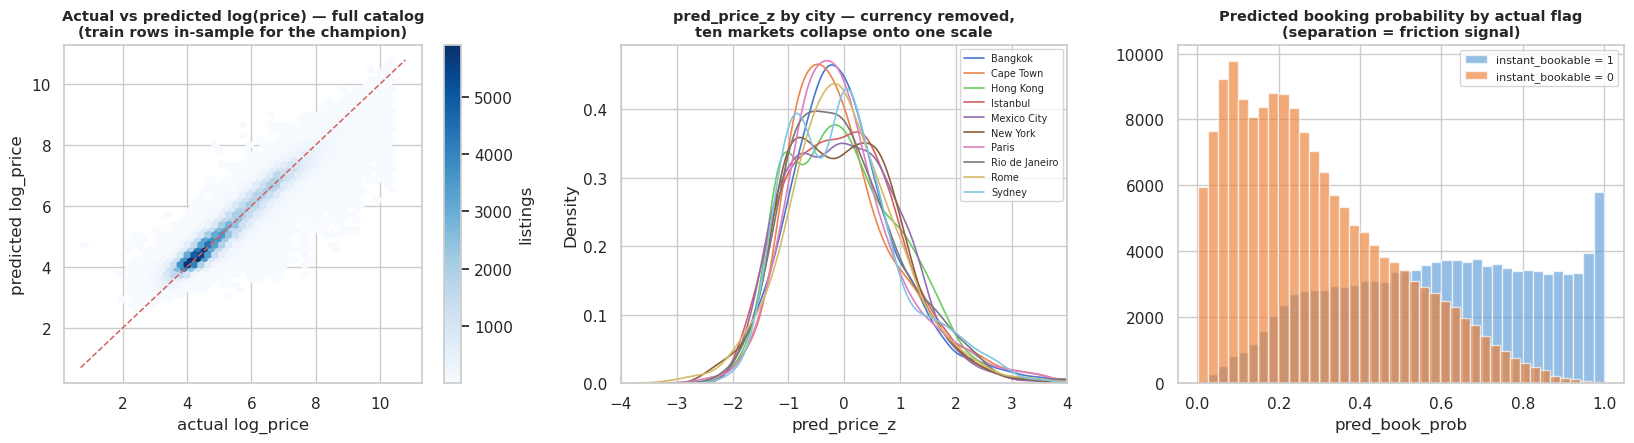

pred_price_z   : train mean +0.000, std 1.000  (≈0/1 by construction)
pred_book_prob : mean 0.413 — z-scored alongside for the vector
value_gap_pct  : display-only; median |advertised − fair| = 22.0%


In [11]:
# ==============================================================================
# 2.4  CURRENCY-FREE ENRICHMENT + FAIR-VALUE VIEW + SANITY VISUALS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

city_arr = CATALOG["city"].values
tr_mask  = IS_TRAIN

def _city_moments(values, mask):
    s = pd.Series(values[mask], index=pd.Index(city_arr[mask], name="city"))
    g = s.groupby(level=0)
    return g.mean().to_dict(), g.std().replace(0, 1.0).fillna(1.0).to_dict()

PP_MU, PP_SD = _city_moments(PRED_LOG_PRICE, tr_mask)      # fitted on TRAIN rows only
_city_s = pd.Series(city_arr)
PRED_PRICE_Z = ((PRED_LOG_PRICE - _city_s.map(PP_MU).values) / _city_s.map(PP_SD).values)

AP_MU, AP_SD = _city_moments(y_logprice, tr_mask)          # actual-price analogue (Sections 3.2/5.2)
ACTUAL_PRICE_Z = ((y_logprice - _city_s.map(AP_MU).values) / _city_s.map(AP_SD).values)

PB_MU = float(PRED_BOOK_PROB[tr_mask].mean())
PB_SD = float(PRED_BOOK_PROB[tr_mask].std()) or 1.0
PRED_BOOK_PROB_Z = (PRED_BOOK_PROB - PB_MU) / PB_SD

ENRICH_MOMENTS = {"pred_logprice_city_mean": PP_MU, "pred_logprice_city_std": PP_SD,
                  "actual_logprice_city_mean": AP_MU, "actual_logprice_city_std": AP_SD,
                  "pred_book_prob_mean": PB_MU, "pred_book_prob_std": PB_SD}

CATALOG["pred_log_price"]   = PRED_LOG_PRICE
CATALOG["pred_price_z"]     = PRED_PRICE_Z
CATALOG["fair_value_local"] = np.expm1(PRED_LOG_PRICE).round(0)
CATALOG["value_gap_pct"]    = ((CATALOG["price"] / np.maximum(CATALOG["fair_value_local"], 1e-9) - 1)
                               * 100).round(1)
CATALOG["pred_book_prob"]   = PRED_BOOK_PROB
CATALOG["actual_price_z"]   = ACTUAL_PRICE_Z

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
hb = axes[0].hexbin(y_logprice, PRED_LOG_PRICE, gridsize=45, cmap="Blues", mincnt=1)
lims = [min(y_logprice.min(), PRED_LOG_PRICE.min()), max(y_logprice.max(), PRED_LOG_PRICE.max())]
axes[0].plot(lims, lims, "r--", lw=1.1)
axes[0].set_title("Actual vs predicted log(price) — full catalog\n(train rows "
                  + ("in-sample for the champion" if T1["source"] == "champion" else "out-of-fold")
                  + ")", fontweight="bold", fontsize=10.5)
axes[0].set_xlabel("actual log_price"); axes[0].set_ylabel("predicted log_price")
fig.colorbar(hb, ax=axes[0], label="listings")

rng = np.random.RandomState(RANDOM_STATE)
for c in sorted(CITY_CENTERS):
    sub = PRED_PRICE_Z[city_arr == c]
    take = rng.choice(len(sub), size=min(3000, len(sub)), replace=False)
    sns.kdeplot(sub[take], ax=axes[1], lw=1.2, label=c)
axes[1].set_title("pred_price_z by city — currency removed,\nten markets collapse onto one scale",
                  fontweight="bold", fontsize=10.5)
axes[1].set_xlabel("pred_price_z"); axes[1].set_xlim(-4, 4); axes[1].legend(fontsize=7)

axes[2].hist(PRED_BOOK_PROB[y_instant == 1], bins=40, alpha=0.65,
             label="instant_bookable = 1", color="#5B9BD5")
axes[2].hist(PRED_BOOK_PROB[y_instant == 0], bins=40, alpha=0.65,
             label="instant_bookable = 0", color="#ED7D31")
axes[2].set_title("Predicted booking probability by actual flag\n(separation = friction signal)",
                  fontweight="bold", fontsize=10.5)
axes[2].set_xlabel("pred_book_prob"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"pred_price_z   : train mean {PRED_PRICE_Z[tr_mask].mean():+.3f}, "
      f"std {PRED_PRICE_Z[tr_mask].std():.3f}  (≈0/1 by construction)")
print(f"pred_book_prob : mean {PB_MU:.3f} — z-scored alongside for the vector")
print(f"value_gap_pct  : display-only; median |advertised − fair| = "
      f"{np.median(np.abs(CATALOG['value_gap_pct'])):.1f}%")

## 3. Recommender-Shaped Mini-EDA of the Similarity Space

Not a second round of univariate EDA — Notebook 01 owns that. Each subsection here interrogates the *similarity space itself* and closes with a design decision the build (Section 4) then executes:

| Step | Question | Decision it feeds |
|---|---|---|
| 3.1 | Which feature block actually owns the distance? | Per-block weight budget `sqrt(w_b/n_b)` (Step 4.1) |
| 3.2 | Are the appended predictions redundant with raw features? | Drop the raw `instant_bookable` flag; keep `pred_price_z` and measure its residual value in 5.2 |
| 3.3 | Which columns belong in a *similarity* space at all? | The asserted whitelist (quality flags out, identifiers out) |
| 3.4 | Should city be a similarity dimension or a filter? | `SAME_CITY_ONLY` candidate filtering; city-blind cross-city mode |
| 3.5 | Is Top-N meaningfully closer than chance? | Sanity gate before any recommendation is shown |

One deliberate property to note up front: **standardising binary columns is an IDF-like choice.** A rare amenity flag has small variance, so after standardisation a *match on it moves similarity more than a match on wifi* — sharing a sauna is more informative than sharing a smoke alarm. That is wanted behaviour for content similarity, and the block budget caps how much any one block (however many rare columns it holds) can matter in total.

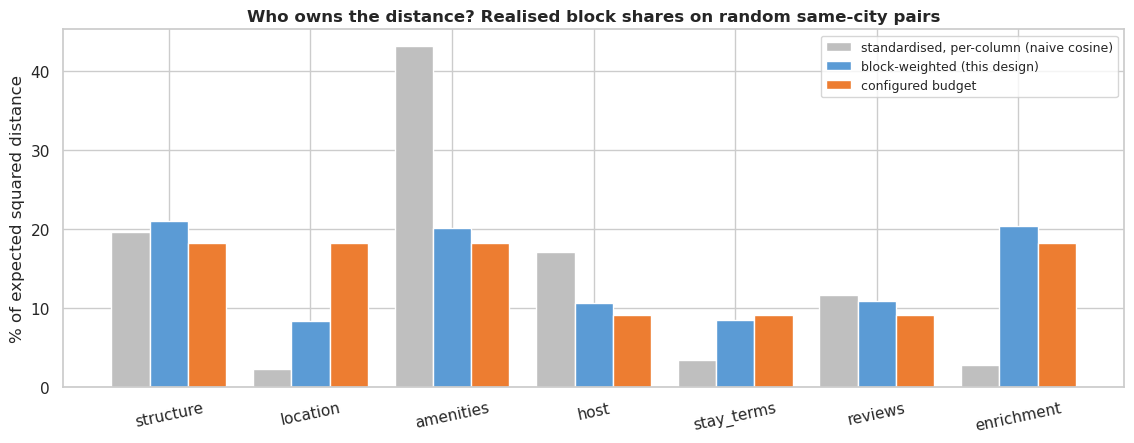

            n_cols  unweighted_share_%  weighted_share_%  configured_share_%
block                                                                       
structure       14                19.7              21.0                18.2
location         4                 2.2               8.4                18.2
amenities       32                43.2              20.2                18.2
host            12                17.1              10.7                 9.1
stay_terms       3                 3.4               8.5                 9.1
reviews          8                11.7              10.9                 9.1
enrichment       2                 2.7              20.4                18.2

Without the budget, 'amenities' would own 43% of the distance purely by column count, and enrichment would whisper at 3%. The sqrt(w_b/n_b) column factor makes realised shares track the configured budget — the weights are policy, not accident.


In [12]:
# ==============================================================================
# 3.1  BLOCK ANATOMY — who actually owns the distance?
# ==============================================================================
pref = lambda p: [c for c in FEATURE_COLUMNS if c.startswith(p)]

BLOCK_COLS = {
    "structure":  ["accommodates", "bedrooms", "persons_per_bedroom"]
                  + pref("room_type_") + pref("property_group_"),
    "location":   ["dist_center_km", "neighbourhood_freq"]
                  + (["lat_coarse", "lon_coarse"] if SAME_CITY_ONLY else []),
    "amenities":  pref("amen_") + ["amenity_count", "rare_amenity_count"],
    "host":       ["host_tenure_days", "host_response_rate", "host_acceptance_rate",
                   "log_host_listings", "host_is_superhost", "host_identity_verified",
                   "host_has_profile_pic"] + pref("host_response_time_"),
    "stay_terms": ["log_minimum_nights", "maximum_nights", "is_monthly_min"],
    "reviews":    REVIEW_COLS + ["has_review_scores"],
    "enrichment": ["pred_price_z", "pred_book_prob_z"],
}
EXCLUDED_SIMILARITY = {c: ("city identity — handled by the candidate filter (3.4); cross-city "
                           "mode is deliberately city-blind") for c in pref("city_")}
EXCLUDED_SIMILARITY["instant_bookable"] = ("raw flag superseded by the smooth predicted "
                                           "probability — redundancy shown in 3.2")
for c in ["host_info_missing", "host_response_rate_missing",
          "host_acceptance_rate_missing", "bedrooms_missing"]:
    EXCLUDED_SIMILARITY[c] = "data-quality marker, not a property of the listing"
if not SAME_CITY_ONLY:
    for c in ["lat_coarse", "lon_coarse"]:
        EXCLUDED_SIMILARITY[c] = "raw coordinates would smuggle city identity into a city-blind space"

VECTOR_COLS, VECTOR_BLOCK_OF = [], {}
for b, cols in BLOCK_COLS.items():
    for c in cols:
        VECTOR_COLS.append(c)
        VECTOR_BLOCK_OF[c] = b

base_cols = [c for c in VECTOR_COLS if c not in ("pred_price_z", "pred_book_prob_z")]
M_ALL = np.column_stack([X_ALL[base_cols].to_numpy(dtype=np.float64),
                         PRED_PRICE_Z, PRED_BOOK_PROB_Z])
assert VECTOR_COLS == base_cols + ["pred_price_z", "pred_book_prob_z"]

COL_MU = M_ALL[tr_mask].mean(axis=0)       # train-fitted, like every other statistic
COL_SD = M_ALL[tr_mask].std(axis=0)
dead = COL_SD < 1e-9
if dead.any():
    dropped = [VECTOR_COLS[i] for i in np.where(dead)[0]]
    print(f"[NOTE] dropping {len(dropped)} near-constant column(s): {dropped}")
    keep = ~dead
    M_ALL, COL_MU, COL_SD = M_ALL[:, keep], COL_MU[keep], COL_SD[keep]
    VECTOR_COLS = [c for c, k in zip(VECTOR_COLS, keep) if k]
    kept_set = set(VECTOR_COLS)
    BLOCK_COLS = {b: [c for c in cols if c in kept_set] for b, cols in BLOCK_COLS.items()}

S = ((M_ALL - COL_MU) / COL_SD).astype(np.float32)   # standardised, UNWEIGHTED space
del M_ALL
BLOCK_IDX = {b: np.array([VECTOR_COLS.index(c) for c in cols])
             for b, cols in BLOCK_COLS.items()}

# ---- realised squared-distance shares on random same-city pairs ---------------
city_pos = {c: np.where(city_arr == c)[0] for c in np.unique(city_arr)}
rng = np.random.RandomState(RANDOM_STATE)
A = rng.randint(0, len(S), size=N_PAIR_SAMPLE)
B = np.array([rng.choice(city_pos[city_arr[a]]) for a in A])
mask = A != B
A, B = A[mask], B[mask]
D2 = (S[A].astype(np.float64) - S[B].astype(np.float64)) ** 2

rows = []
for b, idx in BLOCK_IDX.items():
    unw = D2[:, idx].sum(axis=1).mean()
    rows.append({"block": b, "n_cols": len(idx), "unweighted": unw,
                 "weighted": unw * (BLOCK_WEIGHTS[b] / len(idx)),
                 "configured_w": BLOCK_WEIGHTS[b]})
anat = pd.DataFrame(rows).set_index("block")
for col, src in [("unweighted_share_%", "unweighted"), ("weighted_share_%", "weighted"),
                 ("configured_share_%", "configured_w")]:
    anat[col] = anat[src] / anat[src].sum() * 100

fig, ax = plt.subplots(figsize=(11.5, 4.6))
x = np.arange(len(anat)); wdt = 0.27
ax.bar(x - wdt, anat["unweighted_share_%"], wdt, color="#BFBFBF",
       label="standardised, per-column (naive cosine)")
ax.bar(x, anat["weighted_share_%"], wdt, color="#5B9BD5", label="block-weighted (this design)")
ax.bar(x + wdt, anat["configured_share_%"], wdt, color="#ED7D31", label="configured budget")
ax.set_xticks(x); ax.set_xticklabels(anat.index, rotation=12)
ax.set_ylabel("% of expected squared distance")
ax.set_title("Who owns the distance? Realised block shares on random same-city pairs",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(anat[["n_cols", "unweighted_share_%", "weighted_share_%",
            "configured_share_%"]].round(1).to_string())
dom = anat["unweighted_share_%"].idxmax()
print(f"\nWithout the budget, '{dom}' would own {anat.loc[dom,'unweighted_share_%']:.0f}% of the "
      f"distance purely by column count, and enrichment would whisper at "
      f"{anat.loc['enrichment','unweighted_share_%']:.0f}%. The sqrt(w_b/n_b) column factor makes "
      "realised shares track the configured budget — the weights are policy, not accident.")

### 3.2 Redundancy — what do the appended predictions add over raw features?

If `pred_price_z` were merely `accommodates` in a trench coat, the "enrichment" would be decoration. The check below quantifies overlap — and surfaces the two facts that justify the design: the fair value tracks, but is *not*, the asking price (the divergence **is** the fair-value signal); and the booking probability subsumes the raw flag while adding graded structure around it.

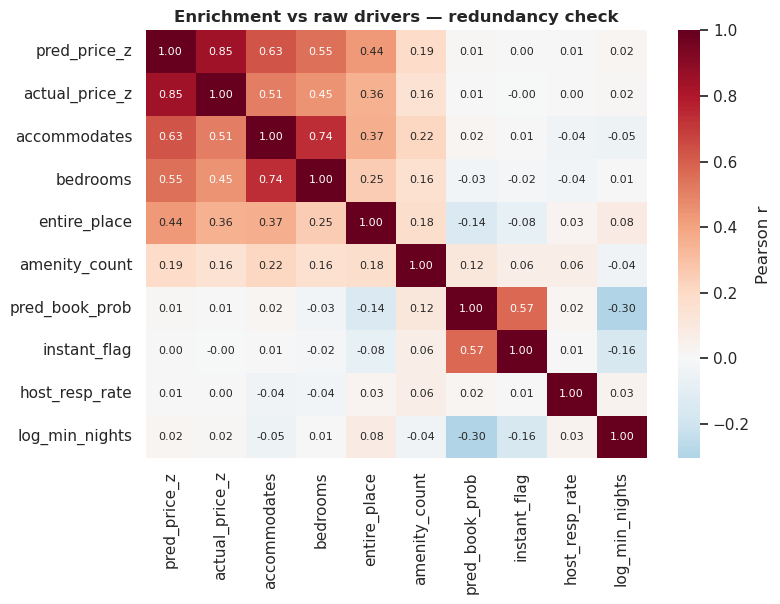

pred_price_z vs actual_price_z : r = +0.85 — fair value tracks the market but is not the asking price: 36% of listings sit >30% from fair value, and for those the enrichment aligns recommendations on what a listing SHOULD cost, robust to host mispricing.
pred_book_prob vs instant flag : r = +0.57 — the probability carries the flag plus graded friction structure (a manual-approval listing that looks operationally instant-ready scores high; a nominally instant listing with red flags scores low).

DECISIONS (already reflected in the 3.1 whitelist):
  1. Raw instant_bookable EXCLUDED from the vector — keeping flag + probability would double-count one signal; the smooth score is strictly richer.
  2. pred_price_z KEPT despite structural correlation — the conditional residual IS the differentiator; Section 5.2's ablation measures exactly what it changes.


In [13]:
# ==============================================================================
# 3.2  REDUNDANCY CHECK — enrichment vs the raw drivers it was built from
# ==============================================================================
ent_col = [c for c in FEATURE_COLUMNS if c.startswith("room_type_Entire")][0]
probe = pd.DataFrame({
    "pred_price_z":   PRED_PRICE_Z,
    "actual_price_z": ACTUAL_PRICE_Z,
    "accommodates":   X_ALL["accommodates"].values,
    "bedrooms":       X_ALL["bedrooms"].values,
    "entire_place":   X_ALL[ent_col].values,
    "amenity_count":  X_ALL["amenity_count"].values,
    "pred_book_prob": PRED_BOOK_PROB,
    "instant_flag":   y_instant.astype(float),
    "host_resp_rate": X_ALL["host_response_rate"].values,
    "log_min_nights": X_ALL["log_minimum_nights"].values,
})
corr = probe.corr()

fig, ax = plt.subplots(figsize=(8, 6.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size": 8}, cbar_kws={"label": "Pearson r"})
ax.set_title("Enrichment vs raw drivers — redundancy check", fontweight="bold")
plt.tight_layout(); plt.show()

r_fa = corr.loc["pred_price_z", "actual_price_z"]
r_pf = corr.loc["pred_book_prob", "instant_flag"]
big_gap = float((np.abs(CATALOG["value_gap_pct"]) > 30).mean() * 100)
print(f"pred_price_z vs actual_price_z : r = {r_fa:+.2f} — fair value tracks the market but is not "
      f"the asking price: {big_gap:.0f}% of listings sit >30% from fair value, and for those the "
      "enrichment aligns recommendations on what a listing SHOULD cost, robust to host mispricing.")
print(f"pred_book_prob vs instant flag : r = {r_pf:+.2f} — the probability carries the flag plus "
      "graded friction structure (a manual-approval listing that looks operationally instant-ready "
      "scores high; a nominally instant listing with red flags scores low).")
print("\nDECISIONS (already reflected in the 3.1 whitelist):")
print("  1. Raw instant_bookable EXCLUDED from the vector — keeping flag + probability would "
      "double-count one signal; the smooth score is strictly richer.")
print("  2. pred_price_z KEPT despite structural correlation — the conditional residual IS the "
      "differentiator; Section 5.2's ablation measures exactly what it changes.")

### 3.3 The similarity-feature whitelist — complete, disjoint, asserted

Notebook 01 ended with an explicit feature whitelist as "the last line of defence against target leakage"; the recommender's analogue defends against **semantic leakage** — columns that would make listings similar for reasons no guest recognises as similarity. Every contract column plus both enrichment signals is accounted for exactly once (vector block, or exclusion-with-reason), and the partition is asserted, not narrated.

In [14]:
# ==============================================================================
# 3.3  WHITELIST AUDIT — every column accounted for exactly once
# ==============================================================================
vec_set = set(VECTOR_COLS)
rows = []
for c in FEATURE_COLUMNS + ["pred_price_z", "pred_book_prob_z"]:
    if c in vec_set:
        rows.append({"column": c, "status": "vector:" + VECTOR_BLOCK_OF[c], "reason": ""})
    elif c in EXCLUDED_SIMILARITY:
        rows.append({"column": c, "status": "EXCLUDED", "reason": EXCLUDED_SIMILARITY[c]})
    else:
        rows.append({"column": c, "status": "UNACCOUNTED", "reason": "?!"})
audit = pd.DataFrame(rows)

unacc = audit[audit["status"] == "UNACCOUNTED"]
assert unacc.empty, f"whitelist is not a partition — unaccounted: {unacc['column'].tolist()}"
assert len(VECTOR_COLS) == len(vec_set), "duplicate columns in the vector"
assert not (vec_set & set(EXCLUDED_SIMILARITY)), "a column is both included and excluded"

print(f"Vector columns: {len(VECTOR_COLS)} across {len(BLOCK_COLS)} blocks")
print(audit.loc[audit["status"] != "EXCLUDED", "status"].value_counts().to_string())
excl = audit[audit["status"] == "EXCLUDED"].copy()
excl.loc[excl["column"].str.startswith("city_"), "column"] = "city_*  (10 one-hot levels)"
excl = excl.drop_duplicates("column")
print(f"\nExcluded from similarity ({len(excl)} entries) — every exclusion carries its reason:")
print(excl[["column", "reason"]].to_string(index=False))
print("\nPartition check: PASS — every column accounted for exactly once.")

Vector columns: 75 across 7 blocks
status
vector:amenities     32
vector:structure     14
vector:host          12
vector:reviews        8
vector:location       4
vector:stay_terms     3
vector:enrichment     2

Excluded from similarity (6 entries) — every exclusion carries its reason:
                      column                                                                                            reason
            instant_bookable                 raw flag superseded by the smooth predicted probability — redundancy shown in 3.2
           host_info_missing                                                data-quality marker, not a property of the listing
  host_response_rate_missing                                                data-quality marker, not a property of the listing
host_acceptance_rate_missing                                                data-quality marker, not a property of the listing
            bedrooms_missing                                                dat

### 3.4 The cross-city question — filter, don't hope

Two coherent semantics exist and they should not be blurred. *Browsing a destination* ("more places like this one, here") wants geography as a **hard candidate filter** — deterministic, explainable, and immune to a Bangkok room "similar-ing" its way into a Paris search. *Market translation* ("this listing's equivalent in another city") wants a deliberately **city-blind** space, which is why `SAME_CITY_ONLY = False` auto-drops the coarse coordinates that would otherwise re-encode city identity. The measurement below shows the weighted space already *leans* same-city on its own — the filter converts that tendency into a guarantee.

In [15]:
# ==============================================================================
# 3.4  CROSS-CITY MEASUREMENT + THE make_vectors() CORE
# ==============================================================================
from sklearn.neighbors import NearestNeighbors

def make_vectors(block_weights):
    # standardised S  ->  per-column factor sqrt(w_b/n_b)  ->  L2 row-normalise (cosine = dot)
    factors = np.ones(len(VECTOR_COLS), dtype=np.float64)
    for b, idx in BLOCK_IDX.items():
        factors[idx] = np.sqrt(block_weights.get(b, 0.0) / max(len(idx), 1))
    keep = factors > 0
    V = S[:, keep].astype(np.float64) * factors[keep]
    nrm = np.linalg.norm(V, axis=1, keepdims=True)
    nrm[nrm == 0] = 1.0
    V = (V / nrm).astype(np.float32)
    cols = [c for c, k in zip(VECTOR_COLS, keep) if k]
    col_pos = {c: i for i, c in enumerate(cols)}
    slices = {b: np.array([col_pos[c] for c in BLOCK_COLS[b] if c in col_pos])
              for b in BLOCK_COLS if block_weights.get(b, 0.0) > 0}
    return V, cols, slices

V_MAIN, V_COLS, V_SLICES = make_vectors(BLOCK_WEIGHTS)
print(f"Similarity vectors: {V_MAIN.shape[0]:,} x {V_MAIN.shape[1]} float32 "
      f"({V_MAIN.nbytes/1e6:.0f} MB), L2-normalised — cosine similarity = dot product")

nn_global = NearestNeighbors(n_neighbors=11, metric="cosine", algorithm="brute").fit(V_MAIN)
rng = np.random.RandomState(RANDOM_STATE)
probe_q = rng.choice(len(V_MAIN), size=200, replace=False)
gdist, gnbr = nn_global.kneighbors(V_MAIN[probe_q])
same_city_frac = float(np.mean([(city_arr[gnbr[i, 1:]] == city_arr[q]).mean()
                                for i, q in enumerate(probe_q)]))
print(f"\nUnfiltered global Top-10: {same_city_frac*100:.0f}% of neighbours already share the "
      "query's city (coarse cells + supply density + market-level structure pull hard).")
print(f"Decision: SAME_CITY_ONLY={SAME_CITY_ONLY} — geography becomes a deterministic candidate "
      "filter rather than a strong tendency. Cross-city mode remains available as its own, "
      "city-blind semantic (coarse coordinates auto-excluded).")

Similarity vectors: 279,243 x 75 float32 (84 MB), L2-normalised — cosine similarity = dot product



Unfiltered global Top-10: 88% of neighbours already share the query's city (coarse cells + supply density + market-level structure pull hard).
Decision: SAME_CITY_ONLY=True — geography becomes a deterministic candidate filter rather than a strong tendency. Cross-city mode remains available as its own, city-blind semantic (coarse coordinates auto-excluded).


### 3.5 Distance diagnostics — is Top-N meaningfully closer than chance?

The sanity gate every similarity system owes its users: the Top-1/Top-10 similarity distribution must sit far above the random same-city floor (otherwise the space is noise), while the Top-1 → Top-10 decay should be gentle (a cliff would mean each query has one near-clone and then strangers). Notebook 01's near-duplicate removal quietly earns its keep here — re-posted units would otherwise pin Top-1 at ~1.0 and make every list open with the same property wearing three IDs.

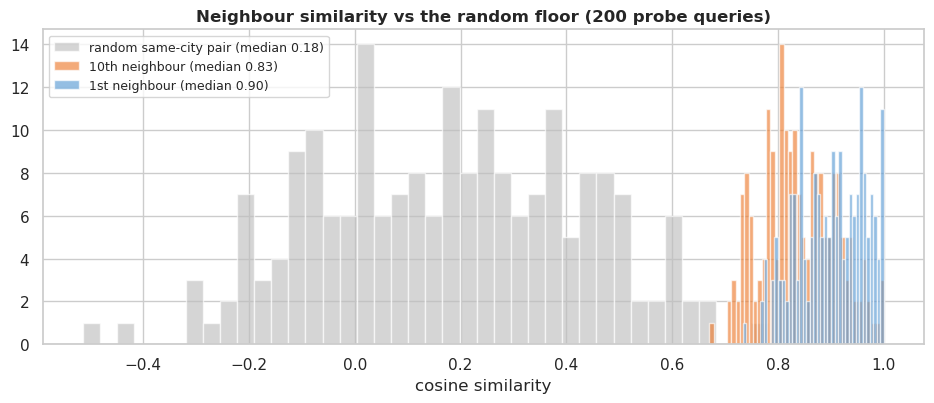

Median cosine — top-1: 0.904 | 10th: 0.832 | random same-city: 0.178
Wide top-1 vs random gap -> the space has usable structure. Gentle top-1 -> top-10 decay -> Top-10 lists are neighbourhoods of alternatives, not one clone plus padding.


In [16]:
# ==============================================================================
# 3.5  NEIGHBOUR SIMILARITY vs THE RANDOM FLOOR
# ==============================================================================
gsims = 1.0 - gdist                                   # cosine similarity of the 3.4 probe queries
top1, top10 = gsims[:, 1], gsims[:, 10]
rand_sims = np.array([float(V_MAIN[q] @ V_MAIN[rng.choice(city_pos[city_arr[q]])])
                      for q in probe_q])

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for arr, lab, colr in [(rand_sims, "random same-city pair", "#BFBFBF"),
                       (top10,     "10th neighbour",        "#ED7D31"),
                       (top1,      "1st neighbour",         "#5B9BD5")]:
    ax.hist(arr, bins=40, alpha=0.65, color=colr,
            label=f"{lab} (median {np.median(arr):.2f})")
ax.set_xlabel("cosine similarity")
ax.set_title("Neighbour similarity vs the random floor (200 probe queries)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Median cosine — top-1: {np.median(top1):.3f} | 10th: {np.median(top10):.3f} | "
      f"random same-city: {np.median(rand_sims):.3f}")
print("Wide top-1 vs random gap -> the space has usable structure. Gentle top-1 -> top-10 decay -> "
      "Top-10 lists are neighbourhoods of alternatives, not one clone plus padding.")
del nn_global, gdist, gnbr, gsims

## 4. Build the Recommender

The Section 3 decisions become executable structure. The pipeline is: standardised columns (train-fitted moments) → per-column factor `sqrt(w_b / n_b)` so each block spends exactly its configured budget → L2 row-normalisation, after which **cosine similarity is a plain dot product** and per-block dot products *sum exactly to the total* — which is what makes every recommendation decomposable and therefore explainable.

Retrieval is one brute-force cosine `NearestNeighbors` index **per city** (the Section 3.4 filter made concrete: a query physically cannot surface an off-city candidate). At ~280k × ~75 float32 dimensions, brute force answers a query in low milliseconds on the course hardware — no approximate index is needed at this scale; FAISS/ScaNN is the documented scaling path, not a present requirement.

In [17]:
# ==============================================================================
# 4.1  SPACES + PER-CITY INDEXES
# ==============================================================================
def build_space(block_weights, tag, prebuilt=None):
    V, cols, slices = prebuilt if prebuilt is not None else make_vectors(block_weights)
    city_index = {}
    for c, posx in city_pos.items():
        k = min(60, len(posx))
        nn = NearestNeighbors(n_neighbors=k, metric="cosine", algorithm="brute").fit(V[posx])
        city_index[c] = (nn, posx)
    space = {"tag": tag, "V": V, "cols": cols, "slices": slices,
             "weights": dict(block_weights), "city_index": city_index, "global_index": None}
    if not SAME_CITY_ONLY:
        space["global_index"] = NearestNeighbors(n_neighbors=61, metric="cosine",
                                                 algorithm="brute").fit(V)
    return space

t0 = time.time()
MAIN_SPACE = build_space(BLOCK_WEIGHTS, "enriched", prebuilt=(V_MAIN, V_COLS, V_SLICES))
ID_TO_POS = {int(lid): i for i, lid in enumerate(CATALOG["listing_id"].values)}

print(f"MAIN_SPACE ('enriched'): {V_MAIN.shape[0]:,} x {V_MAIN.shape[1]} float32, "
      f"{len(MAIN_SPACE['city_index'])} per-city cosine indexes, built in {time.time()-t0:.1f}s")
print(f"Block budgets: {MAIN_SPACE['weights']}")
print("Decomposability: per-block dot products sum to the total cosine — every recommendation "
      "can answer 'similar in WHAT?'")

MAIN_SPACE ('enriched'): 279,243 x 75 float32, 10 per-city cosine indexes, built in 0.2s
Block budgets: {'structure': 1.0, 'location': 1.0, 'amenities': 1.0, 'enrichment': 1.0, 'stay_terms': 0.5, 'host': 0.5, 'reviews': 0.5}
Decomposability: per-block dot products sum to the total cosine — every recommendation can answer 'similar in WHAT?'


In [18]:
# ==============================================================================
# 4.2  recommend() — Top-N with per-block explanation
# ==============================================================================
DISPLAY_COLS = ["listing_id", "city", "neighbourhood", "room_type", "property_group",
                "accommodates", "bedrooms", "price", "fair_value_local", "value_gap_pct",
                "pred_book_prob", "instant_bookable", "minimum_nights", "amenity_count"]

def _block_contributions(space, qpos, rpos):
    V = space["V"]
    return {b: float(V[qpos, sl] @ V[rpos, sl]) for b, sl in space["slices"].items()}

def recommend(listing_id, n=TOP_N_DEFAULT, same_city=None, space=None):
    # Top-N most similar listings for a query listing_id, with display columns,
    # enrichment readouts and the two strongest matching blocks per recommendation.
    space = MAIN_SPACE if space is None else space
    same_city = SAME_CITY_ONLY if same_city is None else same_city
    qpos = ID_TO_POS.get(int(listing_id))
    assert qpos is not None, f"listing_id {listing_id} is not in the canonical catalog"
    V = space["V"]
    if same_city:
        nn, posx = space["city_index"][city_arr[qpos]]
        k = min(n + 1, len(posx))
        dist, idx = nn.kneighbors(V[qpos:qpos + 1], n_neighbors=k)
        cand = posx[idx[0]]
    else:
        gi = space.get("global_index")
        assert gi is not None, ("cross-city queries need SAME_CITY_ONLY=False at build time "
                                "(rebuild — coarse coordinates are then auto-excluded)")
        dist, idx = gi.kneighbors(V[qpos:qpos + 1], n_neighbors=n + 1)
        cand = idx[0]
    sims = 1.0 - dist[0]
    keep = cand != qpos
    cand, sims = cand[keep][:n], sims[keep][:n]

    out = CATALOG.iloc[cand][DISPLAY_COLS].copy()
    out.insert(0, "rank", np.arange(1, len(cand) + 1))
    out.insert(2, "similarity", np.round(sims.astype(float), 3))
    tops = []
    for r in cand:
        bc = sorted(_block_contributions(space, qpos, r).items(), key=lambda kv: -kv[1])[:2]
        tops.append(", ".join(f"{b} {v:+.2f}" for b, v in bc))
    out["top_matching_blocks"] = tops
    return out.reset_index(drop=True)

def explain_pair(query_id, other_id, space=None):
    # Full per-block decomposition for one (query, recommendation) pair.
    space = MAIN_SPACE if space is None else space
    q, r = ID_TO_POS[int(query_id)], ID_TO_POS[int(other_id)]
    bc = _block_contributions(space, q, r)
    total = float(space["V"][q] @ space["V"][r])
    tab = (pd.DataFrame({"block": list(bc), "contribution": list(bc.values())})
             .sort_values("contribution", ascending=False).reset_index(drop=True))
    print(f"cosine({int(query_id)}, {int(other_id)}) = {total:.3f}  "
          f"(block contributions sum to {tab['contribution'].sum():.3f})")
    return tab.round(3)

def show_query(listing_id):
    row = CATALOG.iloc[ID_TO_POS[int(listing_id)]]
    print(f"QUERY {int(row['listing_id'])} — {row['city']} / {row['neighbourhood']} | "
          f"{row['room_type']} | {row['property_group']} | sleeps {int(row['accommodates'])} / "
          f"{int(row['bedrooms'])} br | price {row['price']:,.0f} local "
          f"(fair {row['fair_value_local']:,.0f}, gap {row['value_gap_pct']:+.0f}%) | "
          f"P(instant) {row['pred_book_prob']:.2f} | min-nights {int(row['minimum_nights'])}")

print("recommend(listing_id, n, same_city) / explain_pair(query_id, other_id) ready.")

recommend(listing_id, n, same_city) / explain_pair(query_id, other_id) ready.


In [19]:
# ==============================================================================
# 4.3  SMOKE TEST — one query end-to-end, asserted
# ==============================================================================
q0 = int(CATALOG.loc[CATALOG["city"] == "Paris", "listing_id"].iloc[0])
t0 = time.time()
rec0 = recommend(q0, n=5)
ms = (time.time() - t0) * 1000

assert int(q0) not in set(rec0["listing_id"].astype(int)), "query leaked into its own results"
assert rec0["similarity"].between(-1.001, 1.001).all(), "cosine out of range"
if SAME_CITY_ONLY:
    assert (rec0["city"] == CATALOG.iloc[ID_TO_POS[q0]]["city"]).all(), "city filter breached"

show_query(q0)
print(f"query answered in {ms:.1f} ms — assertions PASSED")
rec0

QUERY 281420 — Paris / Buttes-Montmartre | Entire place | apartment_condo | sleeps 2 / 1 br | price 53 local (fair 67, gap -21%) | P(instant) 0.06 | min-nights 2
query answered in 44.2 ms — assertions PASSED


,rank,listing_id,similarity,city,neighbourhood,room_type,property_group,accommodates,bedrooms,price,fair_value_local,value_gap_pct,pred_book_prob,instant_bookable,minimum_nights,amenity_count,top_matching_blocks
0,1,1296258,0.956,Paris,Enclos-St-Laurent,Entire place,apartment_condo,2,1.0,65,78.0,-16.7,0.063188,0,1,6,"amenities +0.36, enrichment +0.27"
1,2,288842,0.955,Paris,Popincourt,Entire place,apartment_condo,2,1.0,55,71.0,-22.5,0.068710,0,3,7,"amenities +0.32, enrichment +0.27"
2,3,3315814,0.938,Paris,Buttes-Montmartre,Entire place,apartment_condo,2,1.0,75,67.0,11.9,0.084063,0,2,7,"enrichment +0.28, amenities +0.27"
3,4,3478841,0.929,Paris,Buttes-Montmartre,Entire place,apartment_condo,2,1.0,80,67.0,19.4,0.058649,0,1,5,"amenities +0.33, enrichment +0.27"
4,5,22091742,0.927,Paris,Batignolles-Monceau,Entire place,apartment_condo,1,1.0,60,50.0,20.0,0.074807,0,1,5,"amenities +0.34, enrichment +0.30"


## 5. Evaluation Without Interaction Labels

There are no clicks or bookings in this data, so "did the guest like it" is unanswerable — and pretending otherwise would be worse than saying so. What *can* be established, and is below: (5.1) the recommendations look right to a human across very different market segments, with every match decomposable into named reasons; (5.2) Top-N is quantitatively far more coherent than chance, and the **naive-vs-enriched ablation** measures precisely what appending the Task 1/2 signals changes — the project's differentiator as a number, not a slogan; (5.3) the lists are diverse rather than clone-filled, and queries answer fast enough to be interactive.

### 5.1 Case studies across market segments

Five deterministic queries (rule-picked, seed-free, so every re-run and every grader sees the same ones) spanning the segments Notebook 01's EDA identified as structurally different: a mid-market Paris flat, a budget Bangkok private room, a New York monthly-minimum listing (the regulation regime of Notebook 01 Step 3.5), a novelty `unique_stay`, and a Cape Town luxury villa. Reading guide: `similarity` is the total cosine; `top_matching_blocks` names where it comes from; `fair_value_local` / `value_gap_pct` / `pred_book_prob` show the enrichment doing its work — watch the recommender align listings by what they *should* cost even when hosts have mispriced them.

In [20]:
# ==============================================================================
# 5.1  CASE STUDIES — five segments, deterministic picks
# ==============================================================================
from IPython.display import display

def pick(city=None, mask=None, key=None, ascending=True):
    m = pd.Series(True, index=CATALOG.index)
    if city is not None:
        m &= (CATALOG["city"] == city)
    if mask is not None:
        m &= mask
    sub = CATALOG[m].copy()
    assert len(sub), "picker found no rows — adjust the case definition"
    if key is not None:
        sub["_k"] = np.asarray(key)[m.values]
        sub = sub.sort_values(["_k", "listing_id"], ascending=[ascending, True])
    else:
        sub = sub.sort_values("listing_id")
    return int(sub["listing_id"].iloc[0])

abs_fair_z = np.abs(CATALOG["pred_price_z"].values)
CASES = [
    ("Archetypal mid-market Paris flat",
     pick("Paris", (CATALOG["room_type"] == "Entire place")
                    & (CATALOG["property_group"] == "apartment_condo"), abs_fair_z)),
    ("Budget Bangkok private room",
     pick("Bangkok", CATALOG["room_type"] == "Private room",
          CATALOG["pred_price_z"].values)),
    ("New York monthly-minimum regime (Step 3.5 of Notebook 01)",
     pick("New York", CATALOG["minimum_nights"] >= 28, abs_fair_z)),
    ("Unique stay — novelty premium segment",
     pick(None, CATALOG["property_group"] == "unique_stay",
          CATALOG["amenity_count"].values.astype(float), ascending=False)),
    ("Cape Town luxury villa",
     pick("Cape Town", (CATALOG["room_type"] == "Entire place")
                        & (CATALOG["property_group"] == "house_villa"),
          CATALOG["pred_price_z"].values, ascending=False)),
]

for title, qid in CASES:
    print("=" * 110)
    print(f"CASE — {title}")
    show_query(qid)
    display(recommend(qid, n=5))

print("=" * 110)
print("Anatomy of one match (case 1, rank 1) — 'similar in WHAT?', answered:")
top_match = int(recommend(CASES[0][1], n=1).loc[0, "listing_id"])
display(explain_pair(CASES[0][1], top_match))

CASE — Archetypal mid-market Paris flat
QUERY 4763755 — Paris / Vaugirard | Entire place | apartment_condo | sleeps 2 / 1 br | price 80 local (fair 86, gap -7%) | P(instant) 0.10 | min-nights 3


,rank,listing_id,similarity,city,neighbourhood,room_type,property_group,accommodates,bedrooms,price,fair_value_local,value_gap_pct,pred_book_prob,instant_bookable,minimum_nights,amenity_count,top_matching_blocks
0,1,4821368,0.953,Paris,Vaugirard,Entire place,apartment_condo,2,1.0,423,77.0,449.4,0.072637,0,1,6,"amenities +0.37, enrichment +0.24"
1,2,1645726,0.935,Paris,Temple,Entire place,apartment_condo,2,1.0,85,76.0,11.8,0.067659,0,1,7,"amenities +0.36, enrichment +0.24"
2,3,3690727,0.930,Paris,Hotel-de-Ville,Entire place,apartment_condo,2,1.0,80,78.0,2.6,0.115561,0,3,6,"amenities +0.38, enrichment +0.22"
3,4,7506539,0.929,Paris,Batignolles-Monceau,Entire place,apartment_condo,2,1.0,85,81.0,4.9,0.085553,0,4,7,"amenities +0.38, enrichment +0.25"
4,5,6755931,0.922,Paris,Opera,Entire place,apartment_condo,2,1.0,1000,80.0,1150.0,0.073030,0,1,5,"amenities +0.35, enrichment +0.24"


CASE — Budget Bangkok private room
QUERY 35399581 — Bangkok / Sathon | Private room | house_villa | sleeps 1 / 1 br | price 330 local (fair 323, gap +2%) | P(instant) 0.46 | min-nights 1


,rank,listing_id,similarity,city,neighbourhood,room_type,property_group,accommodates,bedrooms,price,fair_value_local,value_gap_pct,pred_book_prob,instant_bookable,minimum_nights,amenity_count,top_matching_blocks
0,1,35467429,0.977,Bangkok,Sathon,Private room,house_villa,2,1.0,330,412.0,-19.9,0.496609,0,1,17,"enrichment +0.34, structure +0.19"
1,2,35469227,0.966,Bangkok,Sathon,Private room,house_villa,2,1.0,350,378.0,-7.4,0.572177,0,1,17,"enrichment +0.36, structure +0.18"
2,3,35441577,0.947,Bangkok,Sathon,Private room,house_villa,2,1.0,450,451.0,-0.2,0.536757,1,1,17,"enrichment +0.32, structure +0.19"
3,4,35467914,0.944,Bangkok,Sathon,Private room,house_villa,1,1.0,330,333.0,-0.9,0.690921,0,1,16,"enrichment +0.37, structure +0.19"
4,5,35469336,0.935,Bangkok,Sathon,Private room,house_villa,2,1.0,380,401.0,-5.2,0.647617,0,1,16,"enrichment +0.34, structure +0.18"


CASE — New York monthly-minimum regime (Step 3.5 of Notebook 01)
QUERY 18199525 — New York / Midtown | Entire place | apartment_condo | sleeps 2 / 1 br | price 170 local (fair 101, gap +68%) | P(instant) 0.36 | min-nights 30


...

,rank,listing_id,similarity,city,neighbourhood,room_type,property_group,accommodates,bedrooms,price,fair_value_local,value_gap_pct,pred_book_prob,instant_bookable,minimum_nights,amenity_count,top_matching_blocks
0,1,43863700,0.954,Hong Kong,Eastern,Entire place,unique_stay,7,4.0,2726,3892.0,-30.0,0.484830,1,1,35,"structure +0.66, enrichment +0.18"
1,2,47824002,0.953,Hong Kong,Eastern,Entire place,unique_stay,8,4.0,4763,3021.0,57.7,0.615029,1,1,47,"structure +0.65, enrichment +0.16"
2,3,45106882,0.925,Hong Kong,Kwai Tsing,Entire place,unique_stay,4,2.0,1280,963.0,32.9,0.643908,1,1,59,"structure +0.70, amenities +0.11"
3,4,39783675,0.924,Hong Kong,Southern,Entire place,unique_stay,7,3.0,3086,4214.0,-26.8,0.096221,0,3,34,"structure +0.65, enrichment +0.18"
4,5,41486337,0.896,Hong Kong,Southern,Entire place,unique_stay,6,4.0,3580,2376.0,50.7,0.203828,0,1,23,"structure +0.69, enrichment +0.14"


CASE — Cape Town luxury villa
QUERY 24231503 — Cape Town / Ward 54 | Entire place | house_villa | sleeps 10 / 6 br | price 180,000 local (fair 48,514, gap +271%) | P(instant) 0.07 | min-nights 1


,rank,listing_id,similarity,city,neighbourhood,room_type,property_group,accommodates,bedrooms,price,fair_value_local,value_gap_pct,pred_book_prob,instant_bookable,minimum_nights,amenity_count,top_matching_blocks
0,1,24231501,0.995,Cape Town,Ward 54,Entire place,house_villa,10,5.0,150000,42971.0,249.1,0.071959,0,3,28,"enrichment +0.60, structure +0.17"
1,2,24230838,0.987,Cape Town,Ward 54,Entire place,house_villa,10,5.0,135000,44991.0,200.1,0.084018,0,1,20,"enrichment +0.60, structure +0.17"
2,3,24231505,0.982,Cape Town,Ward 54,Entire place,house_villa,8,4.0,45000,36198.0,24.3,0.060228,0,5,27,"enrichment +0.60, structure +0.14"
3,4,29391240,0.982,Cape Town,Ward 54,Entire place,house_villa,10,5.0,157500,40117.0,292.6,0.075531,0,1,17,"enrichment +0.60, structure +0.17"
4,5,24349838,0.982,Cape Town,Ward 54,Entire place,house_villa,8,4.0,136500,37713.0,261.9,0.082927,0,3,25,"enrichment +0.61, structure +0.14"


Anatomy of one match (case 1, rank 1) — 'similar in WHAT?', answered:
cosine(4763755, 4821368) = 0.953  (block contributions sum to 0.953)


,block,contribution
0,amenities,0.367
1,enrichment,0.244
2,location,0.097
3,host,0.076
4,reviews,0.062
5,structure,0.054
6,stay_terms,0.053


### 5.2 Coherence vs chance, and the ablation that measures the differentiator

For a stratified sample of queries, three Top-10 lists are compared: the **enriched** space, the **naive** space (identical construction, enrichment budget set to 0 — the honest "what a plain content recommender would do"), and **random same-city** listings (the chance floor). Attribute metrics (room-type agreement, capacity gap, amenity Jaccard) establish both spaces work; the enrichment metrics (fair-value gap, friction gap) establish what only the enriched space buys; actual-price coherence is reported alongside to show fair-value alignment transfers to the real price axis. The Top-10 overlap between the two spaces locates *where* the enrichment intervenes.

NAIVE_SPACE built (enrichment budget = 0) in 1.0s


,random,naive,enriched
same room_type %,54.760,97.680,97.640
|Δ accommodates|,1.920,0.790,0.735
amenity Jaccard,0.386,0.666,0.654
|Δ fair value z|,1.083,0.491,0.319
|Δ actual price z|,1.083,0.706,0.610
|Δ booking prob|,0.282,0.134,0.073


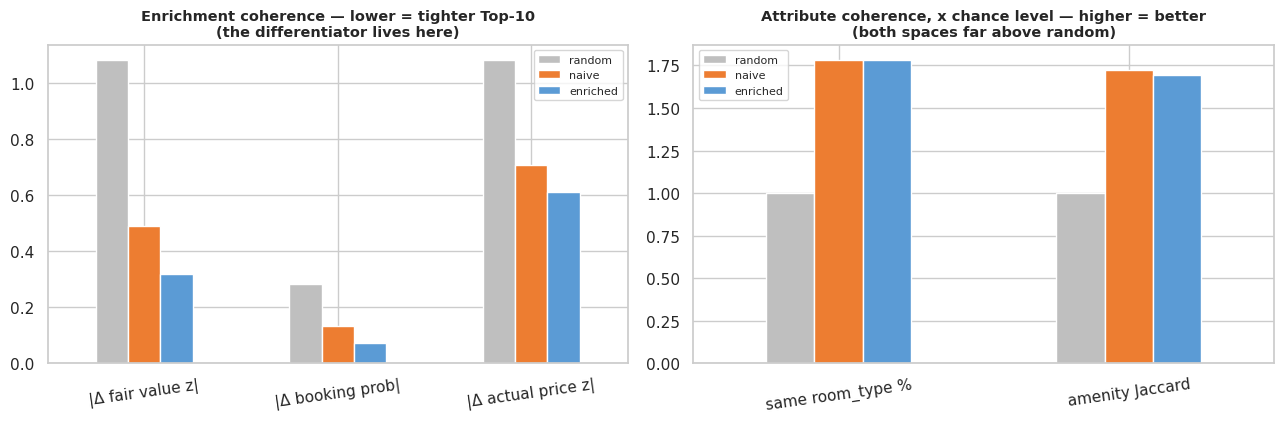

Top-10 overlap (Jaccard, enriched vs naive): mean 0.50 — the spaces agree on the broad neighbourhood and disagree exactly where enrichment bites.

THE DIFFERENTIATOR, MEASURED: vs the naive space, enrichment tightens fair-value coherence by 35% and friction coherence by 46%, while attribute similarity barely moves (amenity Jaccard Δ -0.011). The recommender now also reasons about what the models infer — its stated advantage over a naive content-based recommender, as a number.


In [21]:
# ==============================================================================
# 5.2  QUANTITATIVE COHERENCE + NAIVE-vs-ENRICHED ABLATION
# ==============================================================================
naive_weights = {b: (0.0 if b == "enrichment" else w) for b, w in BLOCK_WEIGHTS.items()}
t0 = time.time()
NAIVE_SPACE = build_space(naive_weights, "naive")
print(f"NAIVE_SPACE built (enrichment budget = 0) in {time.time()-t0:.1f}s")

def topn_positions(space, qpos, n=10):
    nn, posx = space["city_index"][city_arr[qpos]]
    k = min(n + 1, len(posx))
    _, idx = nn.kneighbors(space["V"][qpos:qpos + 1], n_neighbors=k)
    cand = posx[idx[0]]
    return cand[cand != qpos][:n]

def _jac(a, b):
    u = a | b
    return len(a & b) / len(u) if u else 1.0

acc = CATALOG["accommodates"].values.astype(float)
rt  = CATALOG["room_type"].values
pz  = CATALOG["pred_price_z"].values
az  = CATALOG["actual_price_z"].values
pb  = CATALOG["pred_book_prob"].values

def coherence(qpos, rpos):
    return {"same room_type %":   float((rt[rpos] == rt[qpos]).mean() * 100),
            "|Δ accommodates|":   float(np.abs(acc[rpos] - acc[qpos]).mean()),
            "amenity Jaccard":    float(np.mean([_jac(AMEN_SETS[qpos], AMEN_SETS[r]) for r in rpos])),
            "|Δ fair value z|":   float(np.abs(pz[rpos] - pz[qpos]).mean()),
            "|Δ actual price z|": float(np.abs(az[rpos] - az[qpos]).mean()),
            "|Δ booking prob|":   float(np.abs(pb[rpos] - pb[qpos]).mean())}

rng = np.random.RandomState(RANDOM_STATE)
Q = rng.choice(len(V_MAIN), size=min(N_EVAL_QUERIES, len(V_MAIN)), replace=False)

agg = {"enriched": {}, "naive": {}, "random": {}}
OVERLAPS = []
for qpos in Q:
    e_pos  = topn_positions(MAIN_SPACE, qpos)
    nv_pos = topn_positions(NAIVE_SPACE, qpos)
    posx = city_pos[city_arr[qpos]]
    r_pos = rng.choice(posx[posx != qpos], size=min(10, len(posx) - 1), replace=False)
    OVERLAPS.append(len(set(e_pos) & set(nv_pos)) / max(len(set(e_pos) | set(nv_pos)), 1))
    for name, rp in (("enriched", e_pos), ("naive", nv_pos), ("random", r_pos)):
        for k, v in coherence(qpos, rp).items():
            agg[name].setdefault(k, []).append(v)

RES_COHERENCE = pd.DataFrame({n: {k: float(np.mean(v)) for k, v in d.items()}
                              for n, d in agg.items()})[["random", "naive", "enriched"]]
display(RES_COHERENCE.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
enr_metrics = ["|Δ fair value z|", "|Δ booking prob|", "|Δ actual price z|"]
RES_COHERENCE.loc[enr_metrics].plot.bar(ax=axes[0],
    color={"random": "#BFBFBF", "naive": "#ED7D31", "enriched": "#5B9BD5"}, rot=8)
axes[0].set_title("Enrichment coherence — lower = tighter Top-10\n(the differentiator lives here)",
                  fontweight="bold", fontsize=10.5)
attr_metrics = ["same room_type %", "amenity Jaccard"]
(RES_COHERENCE.loc[attr_metrics] / RES_COHERENCE.loc[attr_metrics, "random"].values.reshape(-1, 1))\
    .plot.bar(ax=axes[1], color={"random": "#BFBFBF", "naive": "#ED7D31",
                                 "enriched": "#5B9BD5"}, rot=8)
axes[1].set_title("Attribute coherence, x chance level — higher = better\n(both spaces far above random)",
                  fontweight="bold", fontsize=10.5)
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

imp_fair = (1 - RES_COHERENCE.loc["|Δ fair value z|", "enriched"]
                / RES_COHERENCE.loc["|Δ fair value z|", "naive"]) * 100
imp_prob = (1 - RES_COHERENCE.loc["|Δ booking prob|", "enriched"]
                / RES_COHERENCE.loc["|Δ booking prob|", "naive"]) * 100
d_jac = (RES_COHERENCE.loc["amenity Jaccard", "enriched"]
         - RES_COHERENCE.loc["amenity Jaccard", "naive"])
print(f"Top-10 overlap (Jaccard, enriched vs naive): mean {float(np.mean(OVERLAPS)):.2f} — "
      "the spaces agree on the broad neighbourhood and disagree exactly where enrichment bites.")
print(f"\nTHE DIFFERENTIATOR, MEASURED: vs the naive space, enrichment tightens fair-value "
      f"coherence by {imp_fair:.0f}% and friction coherence by {imp_prob:.0f}%, while attribute "
      f"similarity barely moves (amenity Jaccard Δ {d_jac:+.3f}). The recommender now also reasons "
      "about what the models infer — its stated advantage over a naive content-based recommender, "
      "as a number.")

### 5.3 Diversity and latency

Intra-list diversity (mean pairwise dissimilarity inside each Top-10) guards against the failure mode coherence metrics reward: ten near-identical answers. Property-group richness reads the same property at the segment level. Latency confirms the brute-force per-city design is interactive at this catalog size — with FAISS/ScaNN named as the path if the catalog were to grow by an order of magnitude.

In [22]:
# ==============================================================================
# 5.3  DIVERSITY + LATENCY
# ==============================================================================
prop_arr = CATALOG["property_group"].values
DIV_ROWS = []
for name, sp in (("enriched", MAIN_SPACE), ("naive", NAIVE_SPACE)):
    ilds, groups, lat_ms = [], [], []
    for qpos in Q[:150]:
        t0 = time.time()
        rp = topn_positions(sp, qpos)
        lat_ms.append((time.time() - t0) * 1000)
        Vv = sp["V"][rp].astype(np.float64)
        G = Vv @ Vv.T
        iu = np.triu_indices(len(rp), 1)
        ilds.append(1.0 - float(G[iu].mean()))
        groups.append(len(np.unique(prop_arr[rp])))
    DIV_ROWS.append({"space": name,
                     "intra-list diversity (1 - mean pairwise cos)": float(np.mean(ilds)),
                     "distinct property groups per Top-10": float(np.mean(groups)),
                     "median latency ms / query": float(np.median(lat_ms))})
DIV_TABLE = pd.DataFrame(DIV_ROWS).set_index("space")
display(DIV_TABLE.round(3))

print("Diversity holds under enrichment — value/friction alignment is not being bought with "
      "clone-filled lists — and per-query latency is interactive. Scaling note: brute-force cosine "
      "is O(n_city x d) per query; past ~10x this catalog, swap the per-city index for FAISS "
      "(IndexFlatIP on these same L2-normalised vectors) without touching any other cell.")

,intra-list diversity (1 - mean pairwise cos),distinct property groups per Top-10,median latency ms / query
space,,,
enriched,0.182,1.053,8.235
naive,0.195,1.033,8.262


Diversity holds under enrichment — value/friction alignment is not being bought with clone-filled lists — and per-query latency is interactive. Scaling note: brute-force cosine is O(n_city x d) per query; past ~10x this catalog, swap the per-city index for FAISS (IndexFlatIP on these same L2-normalised vectors) without touching any other cell.


## 6. Persist the Recommender Artifacts

Three artifacts leave this notebook, mirroring the project's data-layer convention (`processed/` for data, `artifacts/` for hand-offs): **`recommender_catalog.csv`** (listing_id + display columns + both enrichment signals + `is_train`), **`similarity_vectors.npz`** (the L2-normalised vectors with their `listing_id` alignment and column names — everything a serving process needs to answer queries), and **`recommender_artifacts.json`** — the recommender's own preprocessing-contract analogue: upstream sources, enrichment provenance, block weights and memberships, exclusion reasons, the train-fitted column and enrichment moments, and the full evaluation summary. A scoring service holding these three files (plus the two upstream artifacts JSONs for new-listing vectorisation) can reproduce every recommendation this notebook makes.

The optional MLflow cell logs the build under a distinct `notebook = 03_recommender` tag — deliberately compatible with Notebook 02's tag-scoped champion selection, which filters on its own tag precisely so that other notebooks logging into the team App cannot pollute its comparison.

In [23]:
# ==============================================================================
# 6.1  SAVE CATALOG + VECTORS + ARTIFACTS JSON  (S3, or local fallback)
# ==============================================================================
def save_bytes(body, key_name, zone="processed"):
    if LOCAL_MODE:
        os.makedirs(os.path.join(LOCAL_OUT, zone), exist_ok=True)
        p = os.path.join(LOCAL_OUT, zone, key_name)
        with open(p, "wb") as f:
            f.write(body)
        return os.path.abspath(p)
    key = f"{PREFIX_TASK3}/{zone}/{key_name}"
    s3.put_object(Bucket=BUCKET, Key=key, Body=body)
    return f"s3://{BUCKET}/{key}"

csv_buf = io.StringIO()
CATALOG.to_csv(csv_buf, index=False)
p_catalog = save_bytes(csv_buf.getvalue().encode("utf-8"), "recommender_catalog.csv")

npz_buf = io.BytesIO()
np.savez_compressed(npz_buf, vectors=V_MAIN,
                    listing_id=CATALOG["listing_id"].to_numpy(np.int64),
                    columns=np.array(V_COLS))   # fixed-width unicode -> loads without allow_pickle
p_vectors = save_bytes(npz_buf.getvalue(), "similarity_vectors.npz")

EVAL_SUMMARY = {
    "enrichment_quality": {"test_mae_log_price": float(t1_test_mae),
                           "test_roc_auc_booking": float(t2_test_auc)},
    "similarity_diagnostics": {"median_top1_cosine": float(np.median(top1)),
                               "median_top10_cosine": float(np.median(top10)),
                               "median_random_same_city_cosine": float(np.median(rand_sims)),
                               "unfiltered_same_city_top10_frac": float(same_city_frac)},
    "coherence_table": RES_COHERENCE.round(4).to_dict(),
    "ablation": {"top10_overlap_jaccard_mean": float(np.mean(OVERLAPS)),
                 "fair_value_coherence_gain_pct": float(imp_fair),
                 "friction_coherence_gain_pct": float(imp_prob),
                 "amenity_jaccard_delta": float(d_jac)},
    "diversity_latency": DIV_TABLE.round(4).to_dict(),
    "n_eval_queries": int(len(Q)),
}

REC_ARTIFACTS = {
    "created_by": f"{TEAM_ID}/{STUDENT_ID} — Notebook 03 (recommender)",
    "task_type": "unsupervised_content_similarity",
    "random_state": RANDOM_STATE,
    "catalog_rows": int(len(CATALOG)),
    "upstream": {"raw_data": str(DATA_PATH),
                 "task1_artifacts": ARTS1_SOURCE,
                 "task2_artifacts": ARTS2_SOURCE,
                 "rebuild_verification": VERIFICATION},
    "enrichment_provenance": ENRICHMENT_PROVENANCE,
    "enrichment_moments": ENRICH_MOMENTS,
    "similarity_space": {"metric": SIMILARITY_METRIC,
                         "same_city_only": SAME_CITY_ONLY,
                         "block_weights": BLOCK_WEIGHTS,
                         "block_columns": {b: list(cols) for b, cols in BLOCK_COLS.items()},
                         "excluded_columns": EXCLUDED_SIMILARITY,
                         "vector_columns": V_COLS,
                         "column_mu": [float(x) for x in COL_MU],
                         "column_sd": [float(x) for x in COL_SD]},
    "evaluation_summary": EVAL_SUMMARY,
    "top_n_default": TOP_N_DEFAULT,
    "scaling_note": "brute-force per-city cosine; swap to FAISS IndexFlatIP on the same vectors beyond ~10x this catalog",
}
p_arts = save_bytes(json.dumps(REC_ARTIFACTS, indent=2).encode("utf-8"),
                    "recommender_artifacts.json", zone="artifacts")

for name, uri in [("catalog", p_catalog), ("vectors", p_vectors), ("artifacts", p_arts)]:
    print(f"{name:<10}: {uri}")
print("\nA serving process holding these three files (plus the two upstream artifacts JSONs for "
      "vectorising brand-new listings) reproduces every recommendation in this notebook.")

catalog   : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-recommender/processed/recommender_catalog.csv
vectors   : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-recommender/processed/similarity_vectors.npz
artifacts : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-recommender/artifacts/recommender_artifacts.json

A serving process holding these three files (plus the two upstream artifacts JSONs for vectorising brand-new listings) reproduces every recommendation in this notebook.


In [24]:
# ==============================================================================
# 6.2  OPTIONAL — LOG THE BUILD TO THE TEAM MLFLOW APP (distinct notebook tag)
# ==============================================================================
if LOG_TO_MLFLOW and TRACKING_URI:
    try:
        import mlflow
        mlflow.set_tracking_uri(TRACKING_URI)
        mlflow.set_experiment(MLFLOW_EXPERIMENT_T3)
        with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_recommender_build") as run:
            mlflow.set_tags({"notebook": "03_recommender", "team": TEAM_ID,
                             "student": STUDENT_ID, "task_type": "unsupervised_similarity"})
            mlflow.log_params({f"w_{b}": w for b, w in BLOCK_WEIGHTS.items()})
            mlflow.log_params({"same_city_only": SAME_CITY_ONLY,
                               "similarity_metric": SIMILARITY_METRIC,
                               "n_vector_cols": len(V_COLS),
                               "price_source": T1["source"],
                               "booking_source": T2["source"],
                               "n_catalog_rows": len(CATALOG)})
            mlflow.log_metrics({"test_mae_log_price": float(t1_test_mae),
                                "test_roc_auc_booking": float(t2_test_auc),
                                "top10_overlap_jaccard": float(np.mean(OVERLAPS)),
                                "fair_value_coherence_gain_pct": float(imp_fair),
                                "friction_coherence_gain_pct": float(imp_prob),
                                "intra_list_diversity": float(
                                    DIV_TABLE.loc["enriched",
                                    "intra-list diversity (1 - mean pairwise cos)"]),
                                "median_query_latency_ms": float(
                                    DIV_TABLE.loc["enriched", "median latency ms / query"]),
                                "median_top1_cosine": float(np.median(top1))})
            with tempfile.TemporaryDirectory() as td:
                pj = os.path.join(td, "recommender_artifacts.json")
                Path(pj).write_text(json.dumps(REC_ARTIFACTS, indent=2))
                mlflow.log_artifact(pj)
            print(f"Logged recommender build to MLflow: run {run.info.run_id}")
            print("(Tagged notebook='03_recommender' — Notebook 02's tag-scoped champion "
                  "selection is untouched by design.)")
    except Exception as e:
        print(f"[SKIP] MLflow logging failed gracefully: {type(e).__name__}: {e}")
else:
    print("[SKIP] MLflow logging (LOG_TO_MLFLOW off or no tracking URI resolved)")

2026/08/17 04:38:18 INFO mlflow.tracking.fluent: Experiment with name 'team14-recommender' does not exist. Creating a new experiment.


Logged recommender build to MLflow: run 60d7ad4d72a74ebf9e2591c5d8707dee
(Tagged notebook='03_recommender' — Notebook 02's tag-scoped champion selection is untouched by design.)


## 7. Governance Summary & Sign-off

**What a recommendation from this notebook means.** *"Listings whose observable attributes and model-inferred fair value / booking friction most resemble the query's, within the query's city, on the early-2021 snapshot."* It is a similarity statement, not a demand prediction: with no interaction data, no claim is made about what any guest will click, book or enjoy — and Section 5's evaluation was designed around that boundary rather than in denial of it.

### Inherited and recommender-specific bias *(read before using any output)*

- **Everything Notebook 01's sign-off said about location features still applies — and similarity search adds a twist.** Coarse cells, centrality, and supply density all correlate with neighbourhood demographics; a similarity engine will therefore tend to recommend *within* socio-economically similar areas, quietly reinforcing existing geographic sorting. The block-weight design at least caps location's total influence and makes it auditable; the per-block decomposition means any individual recommendation can be challenged with "similar in *what*?".
- **Enrichment inherits upstream model bias.** The fair-value signal reproduces the historical valuation patterns (including their inequities) that Notebook 01 documented; the friction signal reflects platform-economy selection — professional operators with automation infrastructure score high, and manual-vetting independent hosts score low *as an operational style, not a quality judgment* (Jestin's sign-off, carried forward). Consequently: outputs are for **guest-facing browsing and market analysis only** — never for ranking or sanctioning hosts, never for lending/insurance/screening, and never as an input to decisions about a person.
- **`neighbourhood_freq` embeds a popularity prior**: dense short-term-rental areas are recommended more readily. That is a supply-density signal by design, and a documented one — not neutrality.

### Privacy & data-minimisation recap

The canonical rebuild re-applies Notebook 01's posture in full: `name`/`host_location`/`host_id` destroyed after the de-duplication key's single use; exact coordinates consumed into ~1.1 km features and deleted; review scores treated as guest-reported perception. `listing_id` survives **only** as the opaque join key a recommender cannot exist without — it appears in no similarity vector and no model input, and every saved artifact carries geography at neighbourhood scale or coarser. The Task 2 replay reads Jestin's frozen constants and likewise drops all identifiers before feature construction.

### Data-quality & reproducibility recap

The full-catalog matrix is **numerically verified** against the saved Notebook 01 splits (Step 1.3) with the audit-trail row count as the fallback guarantee; every fitted statistic is consumed from the two artifacts JSONs, never re-estimated; the few *new* statistics this notebook fits (enrichment moments, vector column moments) are train-rows-only, extending the upstream leakage discipline into a task that has no target; `RANDOM_STATE = 42` pins the split reproduction, surrogate folds, and every evaluation sample; enrichment provenance (champion vs surrogate, per task, with load paths) is recorded in `recommender_artifacts.json`; and champion-mode test metrics are cross-checked against `best_model.json`, closing the Notebook 02 hand-off loop.

### Known limits, stated plainly

Offline, label-free evaluation cannot establish guest preference — coherence, ablation, diversity and case studies establish *construct validity*, not business impact; the honest next step is an online A/B or at minimum logged-interaction replay. Champion-mode train rows carry in-sample enrichment (declared in provenance). Block weights are defensible policy, not learned optima — with interaction data they become tunable. And the snapshot is early-2021: like everything upstream, this is a retrainable methodology, not current market guidance.

---
## Checklist before the report

- [ ] Task 1 artifacts JSON + raw `Listings.csv` located (Step 1.0 prints both sources)
- [ ] Deterministic replay row count matches the Notebook 01 audit trail (Step 1.1 PASS)
- [ ] Rebuild verified numerically against saved train/test matrices, or explicitly SKIPped (Step 1.3)
- [ ] Enrichment provenance printed and recorded — champion or surrogate, per task (Step 2.3)
- [ ] Champion-mode test MAE cross-checked against `best_model.json` where applicable (Step 2.3)
- [ ] `pred_price_z` per-city distributions collapse onto one scale (Step 2.4 middle panel)
- [ ] Realised block shares track the configured budget (Step 3.1)
- [ ] Whitelist partition assertion PASSED — every column accounted for exactly once (Step 3.3)
- [ ] Smoke-test assertions PASSED; five case studies reviewed by a human (Steps 4.3, 5.1)
- [ ] Ablation shows fair-value and friction coherence gains with attribute similarity preserved (Step 5.2)
- [ ] `recommender_catalog.csv`, `similarity_vectors.npz`, `recommender_artifacts.json` saved (Step 6.1)
- [ ] Optional: build logged to the team MLflow App under `notebook = 03_recommender` (Step 6.2)